In [4]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn import preprocessing, metrics
import optuna
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit
import gc
import os

In [1]:
# Source - https://stackoverflow.com/a/20896732
# Posted by pzp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-01, License - CC BY-SA 4.0

import sys
print(sys.version)


3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


In [5]:
df = pd.read_csv('../data/processed/room_monthly_features_v5.2.csv')
df.head()

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und
0,2022-06,3.183108e+07,5.763005e+07,158986.0,350455.0,0.000000,525000.000000,117075.000000,1.000000,2.000000,262500.000000,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2022,6,2022_06,240,4.0,236.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
1,2022-07,3.279046e+07,5.763005e+07,158986.0,350455.0,0.000000,615581.545455,103569.636364,0.545455,2.272727,254484.181818,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,11.0,2022,7,2022_07,248,57.0,191.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
2,2022-08,3.358945e+07,5.308788e+07,158986.0,350455.0,0.054054,564954.054054,114685.675676,1.108108,2.027027,279558.445946,14.0,23.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,0.0,0.0,0.0,0.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,37.0,2022,8,2022_08,248,98.0,150.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
3,2022-09,3.447486e+07,5.763005e+07,158986.0,350455.0,0.000000,452721.692308,91902.538462,1.000000,3.000000,200518.047619,19.0,7.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,0.0,0.0,0.0,0.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,26.0,2022,9,2022_09,240,72.0,168.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
4,2022-10,3.514128e+07,5.708569e+07,158986.0,350455.0,0.000000,469944.512195,100916.146341,1.243902,2.243902,225499.481707,34.0,7.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,0.0,0.0,0.0,0.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,41.0,2022,10,2022_10,248,102.0,146.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0


In [6]:
df['price'] = df['price_per_day'] 
df = df.drop('price_per_day', axis=1)
df.head()

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score,tfidf_beach,tfidf_clean,tfidf_da,tfidf_de,tfidf_der,tfidf_die,tfidf_el,tfidf_en,tfidf_est,tfidf_et,tfidf_friendly,tfidf_good,tfidf_great,tfidf_hotel,tfidf_la,tfidf_le,tfidf_location,tfidf_muy,tfidf_nice,tfidf_place,tfidf_pool,tfidf_que,tfidf_room,tfidf_sehr,tfidf_staff,tfidf_stay,tfidf_super,tfidf_trs,tfidf_un,tfidf_und
0,2022-06,3.183108e+07,5.763005e+07,158986.0,350455.0,0.000000,262500.000000,117075.000000,1.000000,2.000000,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2022,6,2022_06,240,4.0,236.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
1,2022-07,3.279046e+07,5.763005e+07,158986.0,350455.0,0.000000,254484.181818,103569.636364,0.545455,2.272727,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,11.0,2022,7,2022_07,248,57.0,191.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
2,2022-08,3.358945e+07,5.308788e+07,158986.0,350455.0,0.054054,279558.445946,114685.675676,1.108108,2.027027,14.0,23.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,0.0,0.0,0.0,0.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,37.0,2022,8,2022_08,248,98.0,150.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
3,2022-09,3.447486e+07,5.763005e+07,158986.0,350455.0,0.000000,200518.047619,91902.538462,1.000000,3.000000,19.0,7.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,0.0,0.0,0.0,0.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,26.0,2022,9,2022_09,240,72.0,168.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0
4,2022-10,3.514128e+07,5.708569e+07,158986.0,350455.0,0.000000,225499.481707,100916.146341,1.243902,2.243902,34.0,7.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,0.0,0.0,0.0,0.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,41.0,2022,10,2022_10,248,102.0,146.0,0.0,8.0,7.5,7.5,10.0,7.5,7.5,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.51872,0.0,0.0,0.0,0.0,0.0,0.254165,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.81629,0.0,0.0


In [7]:
df.select_dtypes(include=['number']).columns

Index(['id', 'masterId', 'propertyId', 'roomId', 'numChild', 'price',
       'commission', 'range_booking_arrival', 'num_of_nights',
       'status_confirmed', 'status_new', 'subStatus_noShow',
       'subStatus_nonPayment', 'subStatus_none', 'subStatus_walkin',
       'title_Honeymoon_decor', 'title_RO', 'title_Teman_kim_kasih_breakfast',
       'title_Twin_bed', 'arrivalTime_16_30', 'arrivalTime__',
       'voucher_geniuscm', 'groupNote_Room_Only_', 'custom1_Paid_OTA',
       'custom1_Paid_by_OTA_Auto_Adjusted', 'referer_Booking_com',
       'refererEditable_Booking_com', 'reference_45867993_marie',
       'reference_E5593226_ANNA_HUBER', 'reference_EJ4657377_',
       'reference_PAL643451_LUCAS', 'reference_PAM228132',
       'reference_YB7740043', 'channel_booking', 'apiSource_Booking_com',
       'allowChannelUpdate_all', 'allowAutoAction_disable',
       'allowAutoAction_enable', 'allowReview_default',
       'allowCancellation__type_propertyDefault_',
       'cancelTime_2024_08_

In [8]:
import pandas as pd
import numpy as np

def advanced_hybrid_fe(data):
    df = data.copy()
    
    # 1. Pastikan terurut dengan benar agar fitur Shift/Rolling tidak bocor
    df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

    # ======================
    # TIME & SEASON FEATURES (SAFE - No Leakage)
    # ======================
    df['date'] = pd.to_datetime(df['month_period'])
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    
    season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
    df['season_strength'] = df['month'].map(season_map)

    # ======================
    # HOLIDAY & PEAK SEASON FEATURES (SAFE)
    # ======================
    # 1. Peak International Tourist Months (Gili/Lombok is packed in Jul/Aug and late Dec)
    df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
    
    # 2. Eid al-Fitr (Lebaran) Mapping
    # Lebaran shifts every year. Here is the mapping for the month it primarily falls in.
    eid_months = {
        2022: 5,  # May
        2023: 4,  # April
        2024: 4,  # April
        2025: 3,  # March
        2026: 3,  # March
        2027: 3   # March
    }
    
    # Check if the row's month matches the Eid month for that specific year
    df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)

    # 3. High Demand / Holiday Month Flag (Combines Eid and End of Year)
    df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

    # ======================
    # PRICE LAGS & ROLLING (Target Variable)
    # ======================
    price_lags = [1, 2, 3, 6, 12]
    for lag in price_lags:
        df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)

    windows = [3, 6, 12]
    for w in windows:
        df[f'price_roll_mean_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).mean()
        )
        df[f'price_roll_std_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=2).std()
        )
        df[f'price_roll_max_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).max()
        )
        df[f'price_roll_min_{w}'] = df.groupby('roomId')['price_lag_1'].transform(
            lambda x: x.rolling(w, min_periods=1).min()
        )

    df['price_diff_1'] = df['price_lag_1'] - df['price_lag_2']
    df['price_diff_12'] = df['price_lag_1'] - df['price_lag_12']
    df['price_growth_1'] = df['price_diff_1'] / (df['price_lag_2'] + 1e-5)
    df['price_ema_3'] = df.groupby('roomId')['price_lag_1'].transform(
        lambda x: x.ewm(span=3, adjust=False).mean()
    )
    

    # ======================
    # NEW BEHAVIOR & OCCUPANCY LAYS (Preventing Cheating)
    # ======================
    leaky_numerical_cols = [
        'used_room_nights', 'leftover_rooms', 'range_booking_arrival', 
        'num_of_nights', 'commission', 'numChild'
    ]
    
    leaky_numerical_cols = [c for c in leaky_numerical_cols if c in df.columns]

    for col in leaky_numerical_cols:
        for lag in [1, 2, 12]:
            df[f'{col}_lag_{lag}'] = df.groupby('roomId')[col].shift(lag)
        
        df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )

    if 'used_room_nights_lag_1' in df.columns and 'used_room_nights_lag_2' in df.columns:
        df['occupancy_trend'] = df['used_room_nights_lag_1'] - df['used_room_nights_lag_2']

    # ======================
    # SHIFTING ALL OTHER ONE-HOT / CATEGORICAL COLUMNS
    # ======================
    # UPDATE: Added our new holiday features to the "safe" list so they aren't deleted!
    safe_current_month_cols = [
        'id', 'propertyId', 'roomId', 'month_period', 'date', 
        'month', 'quarter', 'year', 'season_strength', 
        'is_peak_season', 'is_eid_month', 'is_major_holiday_month', # <-- New Safe Columns
        'total_capacity_nights', 'price'
    ]
    
    all_leaky_cols = [col for col in df.columns if col not in safe_current_month_cols and not col.endswith(('lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'mean_3', 'mean_6', 'mean_12', 'std_3', 'std_6', 'std_12', 'max_3', 'max_6', 'max_12', 'min_3', 'min_6', 'min_12', 'diff_1', 'diff_12', 'growth_1', 'ema_3', 'occupancy_trend'))]

    for col in all_leaky_cols:
        if col not in leaky_numerical_cols:
            df[f'{col}_lag_1'] = df.groupby('roomId')[col].shift(1)
            
    df['price_to_mean_ratio'] = df['price_lag_1'] / df['price_roll_mean_12']
    df['price_vs_property_avg'] = df['price_lag_1'] / df.groupby('propertyId')['price_lag_1'].transform('mean')
    df['occupancy_price_interaction'] = df['used_room_nights_lag_1'] * df['price_lag_1']      
    # Avoid division by zero
    eps = 1e-5

    # =========================
    # 1. Price vs Rolling Means
    # =========================
    if 'price_roll_mean_12' in df.columns:
        df['price_vs_roll_mean_12'] = df['price_lag_1'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['price_vs_roll_mean_6'] = df['price_lag_1'] / (df['price_roll_mean_6'] + eps)

    # =========================
    # 2. Trend Features
    # =========================
    if 'price_roll_mean_3' in df.columns and 'price_roll_mean_12' in df.columns:
        df['trend_3_vs_12'] = df['price_roll_mean_3'] / (df['price_roll_mean_12'] + eps)

    if 'price_roll_mean_6' in df.columns:
        df['trend_slope'] = df['price_lag_1'] - df['price_roll_mean_6']

    # =========================
    # 3. Occupancy × Price
    # =========================
    if 'used_room_nights_lag_1' in df.columns:
        df['occupancy_price_interaction'] = (
            df['used_room_nights_lag_1'] * df['price_lag_1']
        )

    # =========================
    # 4. Property-relative pricing
    # =========================
    if 'propertyId' in df.columns:
        prop_mean = df.groupby('propertyId')['price_lag_1'].transform('mean')
        prop_std = df.groupby('propertyId')['price_lag_1'].transform('std')

        df['price_vs_property_mean'] = df['price_lag_1'] / (prop_mean + eps)
        df['price_zscore_property'] = (df['price_lag_1'] - prop_mean) / (prop_std + eps)

    # =========================
    # 5. Season interactions
    # =========================
    if 'season_strength' in df.columns:
        df['season_price_interaction'] = df['season_strength'] * df['price_lag_1']

    if 'is_peak_season' in df.columns:
        df['peak_price_interaction'] = df['is_peak_season'] * df['price_lag_1']

    # =========================
    # Optional: Growth × Season
    # =========================
    if 'price_growth_1' in df.columns and 'season_strength' in df.columns:
        df['growth_season_interaction'] = df['price_growth_1'] * df['season_strength']

    # =========================
    # Optional: Occupancy × Season
    # =========================
    if 'occupancy_trend' in df.columns and 'is_peak_season' in df.columns:
        df['occupancy_season_interaction'] = (
            df['occupancy_trend'] * df['is_peak_season']
        )
        
    # Overall market trend per month
    df['global_month_mean_price'] = df.groupby('month_period')['price_lag_1'].transform('mean')

    # Property-level market
    df['property_month_mean_price'] = df.groupby(['propertyId', 'month_period'])['price_lag_1'].transform('mean')
    # ======================
    # DROP THE CHEATING COLUMNS
    # ======================
    df = df.drop(columns=all_leaky_cols)
    
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # ======================
    # ROOM-LEVEL STATISTICAL FEATURES date
    # ======================

    eps = 1e-5

    # # Historical mean / std / median per room (using lagged price to avoid leakage)
    # room_stats = df.groupby('roomId')['price_lag_1']

    # df['room_mean_price'] = room_stats.transform('mean')
    # df['room_median_price'] = room_stats.transform('median')
    # df['room_std_price'] = room_stats.transform('std')

    # # How current price compares to room history
    # df['price_vs_room_mean'] = df['price_lag_1'] / (df['room_mean_price'] + eps)
    # df['price_vs_room_median'] = df['price_lag_1'] / (df['room_median_price'] + eps)

    # # Z-score within room
    # df['price_zscore_room'] = (
    #     df['price_lag_1'] - df['room_mean_price']
    # ) / (df['room_std_price'] + eps)

    # # Coefficient of variation (stability of room pricing)
    # df['room_price_cv'] = df['room_std_price'] / (df['room_mean_price'] + eps)

    # # Rank of current price within room history
    # df['room_price_rank'] = df.groupby('roomId')['price_lag_1'].rank(pct=True)

    # # Rolling room mean trend (short vs long term)
    # df['room_roll_mean_3'] = df.groupby('roomId')['price_lag_1'].transform(
    #     lambda x: x.rolling(3, min_periods=1).mean()
    # )

    # df['room_roll_mean_12'] = df.groupby('roomId')['price_lag_1'].transform(
    #     lambda x: x.rolling(12, min_periods=1).mean()
    # )

    # df['room_trend_3_vs_12'] = df['room_roll_mean_3'] / (df['room_roll_mean_12'] + eps)
    
    ## add new
    # Compute property-level mean price (on TRAIN only if possible)
    # property_mean_price = df.groupby('propertyId')['price'].transform('mean')

    # # Add normalized features
    # df['property_mean_price'] = property_mean_price

    # df['price_vs_property_mean'] = df['price'] / df['property_mean_price']
    # df['price_diff_from_property'] = df['price'] - df['property_mean_price']
    return df

# Cara penggunaan:
data = advanced_hybrid_fe(df)
data['roomId'] = data['roomId'].astype('category')
data['propertyId'] = data['propertyId'].astype('category')

In [98]:
# import pandas as pd
# import numpy as np

# def advanced_hybrid_fe(data):
#     df = data.copy()
    
#     # ======================
#     # 0. PRE-PROCESSING & CLEANING SCHEMA
#     # ======================
#     if 'price_per_day_mean' in df.columns:
#         df['price'] = df['price_per_day_mean']
        
#     if 'propertyId_mean' in df.columns:
#         df['propertyId'] = df['propertyId_mean'].astype(int)
    
#     cols_to_drop_immediately = ['id_mean', 'id_sum', 'masterId_mean', 'masterId_sum', 
#                                 'propertyId_mean', 'propertyId_sum', 'year_month']
#     df = df.drop(columns=[c for c in cols_to_drop_immediately if c in df.columns])

#     df = df.sort_values(['roomId', 'month_period']).reset_index(drop=True)

#     # ======================
#     # 1. TIME, SEASON & HOLIDAY FEATURES (SAFE)
#     # ======================
#     df['date'] = pd.to_datetime(df['month_period'])
#     df['month'] = df['date'].dt.month
#     df['quarter'] = df['date'].dt.quarter
#     df['year'] = df['date'].dt.year
    
#     season_map = {1:0, 2:0, 11:0, 3:1, 4:1, 5:1, 6:1, 10:1, 7:2, 8:2, 9:2, 12:3}
#     df['season_strength'] = df['month'].map(season_map)

#     df['is_peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
#     eid_months = {2022: 5, 2023: 4, 2024: 4, 2025: 3, 2026: 3, 2027: 3}
#     df['is_eid_month'] = df.apply(lambda row: 1 if eid_months.get(row['year']) == row['month'] else 0, axis=1)
#     df['is_major_holiday_month'] = ((df['month'] == 12) | (df['is_eid_month'] == 1)).astype(int)

#     # ======================
#     # 2. DYNAMIC LEAKAGE PREVENTION
#     # ======================
#     safe_current_month_cols = [
#         'roomId', 'propertyId', 'month_period', 'date', 'month', 'quarter', 
#         'year', 'season_strength', 'is_peak_season', 'is_eid_month', 
#         'is_major_holiday_month', 'total_capacity_nights', 'price'
#     ]
    
#     leaky_cols = [col for col in df.columns if col not in safe_current_month_cols]

#     # ======================
#     # 3. GENERATE LAGS FOR ALL LEAKY COLUMNS
#     # ======================
#     for col in leaky_cols:
#         df[f'{col}_lag_1'] = df.groupby('roomId')[col].shift(1)
        
#         # Added review_count and avg_review_score to get lag_2 for momentum tracking
#         if col in ['used_room_nights', 'num_of_nights_mean', 'status_confirmed_sum', 'avg_review_score', 'review_count']:
#             df[f'{col}_lag_2'] = df.groupby('roomId')[col].shift(2)

#     price_lags = [1, 2, 3, 6, 12]
#     for lag in price_lags:
#         df[f'price_lag_{lag}'] = df.groupby('roomId')['price'].shift(lag)
    
#     for w in [3, 6, 12]:
#         df[f'price_roll_mean_{w}'] = df.groupby('roomId')['price_lag_1'].transform(lambda x: x.rolling(w, min_periods=1).mean())
#         df[f'price_roll_std_{w}'] = df.groupby('roomId')['price_lag_1'].transform(lambda x: x.rolling(w, min_periods=2).std())

#     # ======================
#     # 4. REPUTATION & NLP METRICS (NEW)
#     # ======================
#     eps = 1e-5
    
#     # Track Reputation Momentum (Is the property getting better or worse?)
#     if 'avg_review_score_lag_1' in df.columns and 'avg_review_score_lag_2' in df.columns:
#         df['review_score_momentum'] = df['avg_review_score_lag_1'] - df['avg_review_score_lag_2']
#         df['review_volume_trend'] = df['review_count_lag_1'] - df['review_count_lag_2']

#     # Smooth out review scores with a 3-month rolling mean
#     review_cols = [c for c in leaky_cols if 'avg_' in c]
#     for col in review_cols:
#         if f'{col}_lag_1' in df.columns:
#             df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
#                 lambda x: x.rolling(3, min_periods=1).mean()
#             )

#     # Smooth out TF-IDF features: A single month of text is noisy. 
#     # A 3-month rolling mean of TF-IDF captures "persistent themes" (e.g., ongoing construction or a consistently great breakfast).
#     tfidf_cols = [c for c in leaky_cols if c.startswith('tfidf_')]
#     for col in tfidf_cols:
#         if f'{col}_lag_1' in df.columns:
#             df[f'{col}_roll_mean_3'] = df.groupby('roomId')[f'{col}_lag_1'].transform(
#                 lambda x: x.rolling(3, min_periods=1).mean()
#             )

#     # ======================
#     # 5. ADVANCED HOSPITALITY METRICS
#     # ======================
#     if 'used_room_nights_lag_1' in df.columns:
#         df['occupancy_rate_lag_1'] = df['used_room_nights_lag_1'] / (df['total_capacity_nights'] + eps)
        
#         if 'price_lag_1' in df.columns:
#             df['revpar_lag_1'] = df['occupancy_rate_lag_1'] * df['price_lag_1']
            
#         if 'used_room_nights_lag_2' in df.columns:
#             df['occupancy_trend'] = df['used_room_nights_lag_1'] - df['used_room_nights_lag_2']

#     if 'subStatus_noShow_sum_lag_1' in df.columns and 'status_confirmed_sum_lag_1' in df.columns:
#         df['noshow_rate_lag_1'] = df['subStatus_noShow_sum_lag_1'] / (df['status_confirmed_sum_lag_1'] + df['subStatus_noShow_sum_lag_1'] + eps)

#     if 'price_lag_1' in df.columns and 'price_lag_2' in df.columns:
#         df['price_growth_1'] = (df['price_lag_1'] - df['price_lag_2']) / (df['price_lag_2'] + eps)

#     # ======================
#     # 6. CONTEXTUAL & RELATIVE FEATURES
#     # ======================
#     if 'price_lag_1' in df.columns:
#         df['peak_price_interaction'] = df['is_peak_season'] * df['price_lag_1']
        
#         prop_mean = df.groupby('propertyId')['price_lag_1'].transform('mean')
#         df['price_vs_property_mean'] = df['price_lag_1'] / (prop_mean + eps)
        
#         room_stats = df.groupby('roomId')['price_lag_1']
#         df['room_historical_mean'] = room_stats.transform('mean')
#         df['price_vs_room_history'] = df['price_lag_1'] / (df['room_historical_mean'] + eps)

#     # ======================
#     # 7. DROP LEAKY CURRENT-MONTH COLUMNS
#     # ======================
#     df = df.drop(columns=leaky_cols)
    
#     return df
# # # Cara penggunaan:
# data = advanced_hybrid_fe(df)
# data['roomId'] = data['roomId'].astype('category')
# data['propertyId'] = data['propertyId'].astype('category')

In [56]:
data.head()

,month_period,propertyId,roomId,price,year,month,total_capacity_nights,date,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_1,price_lag_2,price_lag_3,price_lag_6,price_lag_12,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,masterId_lag_1,status_confirmed_lag_1,status_new_lag_1,subStatus_noShow_lag_1,subStatus_nonPayment_lag_1,subStatus_none_lag_1,subStatus_walkin_lag_1,title_Honeymoon_decor_lag_1,title_RO_lag_1,title_Teman_kim_kasih_breakfast_lag_1,title_Twin_bed_lag_1,arrivalTime_16_30_lag_1,arrivalTime___lag_1,voucher_geniuscm_lag_1,groupNote_Room_Only__lag_1,custom1_Paid_OTA_lag_1,custom1_Paid_by_OTA_Auto_Adjusted_lag_1,referer_Booking_com_lag_1,refererEditable_Booking_com_lag_1,reference_45867993_marie_lag_1,reference_E5593226_ANNA_HUBER_lag_1,reference_EJ4657377__lag_1,reference_PAL643451_LUCAS_lag_1,reference_PAM228132_lag_1,reference_YB7740043_lag_1,channel_booking_lag_1,apiSource_Booking_com_lag_1,allowChannelUpdate_all_lag_1,allowAutoAction_disable_lag_1,allowAutoAction_enable_lag_1,allowReview_default_lag_1,allowCancellation__type_propertyDefault__lag_1,cancelTime_2024_08_05T03_15_10Z_lag_1,year_month_lag_1,review_count_lag_1,avg_review_score_lag_1,avg_facilities_score_lag_1,avg_comfort_score_lag_1,avg_staff_score_lag_1,avg_value_score_lag_1,avg_clean_score_lag_1,avg_location_score_lag_1,tfidf_beach_lag_1,tfidf_clean_lag_1,tfidf_da_lag_1,tfidf_de_lag_1,tfidf_der_lag_1,tfidf_die_lag_1,tfidf_el_lag_1,tfidf_en_lag_1,tfidf_est_lag_1,tfidf_et_lag_1,tfidf_friendly_lag_1,tfidf_good_lag_1,tfidf_great_lag_1,tfidf_hotel_lag_1,tfidf_la_lag_1,tfidf_le_lag_1,tfidf_location_lag_1,tfidf_muy_lag_1,tfidf_nice_lag_1,tfidf_place_lag_1,tfidf_pool_lag_1,tfidf_que_lag_1,tfidf_room_lag_1,tfidf_sehr_lag_1,tfidf_staff_lag_1,tfidf_stay_lag_1,tfidf_super_lag_1,tfidf_trs_lag_1,tfidf_un_lag_1,tfidf_und_lag_1,price_to_mean_ratio,price_vs_property_avg,occupancy_price_interaction,price_vs_roll_mean_12,price_vs_roll_mean_6,trend_3_vs_12,trend_slope,price_vs_property_mean,price_zscore_property,season_price_interaction,peak_price_interaction,growth_season_interaction,occupancy_season_interaction,global_month_mean_price,property_month_mean_price
0,2022-06,158986.0,350455.0,262500.000000,2022,6,240,2022-06-01,2,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07,158986.0,350455.0,254484.181818,2022,7,248,2022-07-01,3,2,1,0,0,262500.000000,NaN,NaN,NaN,NaN,262500.000000,NaN,262500.000000,262500.000000,262500.000000,NaN,262500.000000,262500.000000,262500.000000,NaN,262500.000000,262500.000000,NaN,NaN,NaN,262500.000000,4.0,NaN,NaN,4.000000,236.0,NaN,NaN,236.000000,1.000000,NaN,NaN,1.000000,2.000000,NaN,NaN,2.000000,117075.000000,NaN,NaN,117075.000000,0.000000,NaN,NaN,0.000000,

In [57]:
# data = data.drop(columns=['commission'])


In [58]:
# The updated useful features based on your latest LightGBM importance scores
# useful_features = [
#     'roomId',
#     'season_strength',
#     'id',
#     'lag_3',
#     'propertyId',
#     'subStatus_none',
#     'month',
#     'status_new',
#     'lag_6',
#     'lag_1',
#     'commission_lag1',
#     'diff_1',
#     'lag_2',
#     'status_confirmed',
#     'growth_1',
#     'roll_std_3',
#     'roll_mean_6',
#     'roll_min_3',
#     'roll_std_6',
#     'roll_std_12',
#     'price',
#     'date',
#     'year'
# ]
# Save this list for your training and testing
# useful_features = [
#     # 'room_historical_avg',      # Top signal: The room's average baseline
#     'id',                       # Record identifier
#     'lag_3', 'lag_6', 'lag_2', 'lag_1',  # Price history
#     'subStatus_none',           # Booking status indicator
#     'growth_1', 'diff_1', 'diff_12',    # Trend & Momentum
#     'month', 'season_strength', # Time context
#     'roomId',                   # Room categorical
#     'roll_std_3', 'roll_std_6', 'roll_std_12', # Volatility
#     'roll_mean_6',              # Moving average
#     'commission_lag1',          # Lagged business costs
#     'status_confirmed',         # Current booking state
#     'status_confirmed_lag1',     # Previous booking state,
#     "propertyId",
#     'price',
#     'date',
#     'year'
# ]

useful_features = [
    # Top 20 Performance Features
    'month', 'price_lag_6', 'occupancy_trend', 
    'roomId', 'price_diff_1', 'range_booking_arrival_lag_1', 'price_growth_1', 
    'price_roll_std_6', 'price_lag_1', 'range_booking_arrival_lag_2', 
    'price_roll_std_3', 'num_of_nights_lag_1', 'price_lag_3', 
    'range_booking_arrival_roll_mean_3', 'num_of_nights_roll_mean_3', 
    'commission_lag_1', 'commission_lag_2', 'num_of_nights_lag_2', 'price_lag_2',
    'season_strength',
    # Must-keep structural columns
    'price', 'month_period', 'propertyId', 'date'
]



In [146]:
# Hardcoded list of features that had 0.0 importance
useless_features = [
    'custom1_Paid_by_OTA_Auto_Adjusted_lag_1',
    'title_Honeymoon_decor_lag_1',
    'arrivalTime___lag_1',
    'subStatus_nonPayment_lag_1',
    'reference_45867993_marie_lag_1',
    'refererEditable_Booking_com_lag_1',
    'referer_Booking_com_lag_1',
    'reference_E5593226_ANNA_HUBER_lag_1',
    'reference_YB7740043_lag_1',
    'reference_EJ4657377__lag_1',
    'reference_PAL643451_LUCAS_lag_1',
    'reference_PAM228132_lag_1',
    'allowChannelUpdate_all_lag_1',
    'apiSource_Booking_com_lag_1',
    'channel_booking_lag_1',
    'allowAutoAction_disable_lag_1',
    'allowCancellation__type_propertyDefault__lag_1',
    'allowReview_default_lag_1',
    'allowAutoAction_enable_lag_1',
    'cancelTime_2024_08_05T03_15_10Z_lag_1'
]
low_importance_cols = [
    "numChild_lag_1",
    "numChild_lag_2",
    "is_eid_month",
    "price_ema_3",
    "arrivalTime_16_30_lag_1",
    "range_booking_arrival_lag_12",
    "occupancy_season_interaction",
    "commission_roll_mean_3",
    "total_capacity_nights",
    "price_roll_min_6",
    "commission_lag_12",
    "price_roll_min_3",
    "used_room_nights_lag_12",
    "price_roll_max_3",
    "commission_lag_1",
    "num_of_nights_lag_12",
    "price_lag_2",
    "price_roll_max_12",
    "subStatus_none_lag_1",
    "title_RO_lag_1",
    "status_new_lag_1",
    "status_confirmed_lag_1",
    "commission_lag_2",
    "range_booking_arrival_roll_mean_3",
    "occupancy_price_interaction",
    "numChild_roll_mean_3",
    "leftover_rooms_lag_1",
    "leftover_rooms_lag_2",
    "leftover_rooms_lag_12",
    "used_room_nights_roll_mean_3",
    "price_roll_mean_3",
    "num_of_nights_roll_mean_3",
    "used_room_nights_lag_12"
]
# Drop them from the dataframe safely (errors='ignore' prevents crashes 
# if a column is already missing)
data = data.drop(columns=useless_features, errors='ignore')
data = data.drop(columns=low_importance_cols, errors='ignore')

print(f"🧹 Successfully dropped up to {len(useless_features)} useless columns!")

🧹 Successfully dropped up to 20 useless columns!


In [128]:
data_old = data

In [94]:
data['price'].mean()

np.float64(684050.0708743833)

In [45]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.ar_model import AutoReg
import gc

# 1. Ensure Stationarity
# We use Log-Difference (Delta of Log Prices) which is standard for making price data stationary
data = data.sort_values('date').reset_index(drop=True)
data['stationary_target'] = np.log1p(data['price']) - np.log1p(data['price_lag_1'])

# 2. Split Data
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

# Drop rows where stationarity calculation isn't possible (first month)
train_data = train_data.dropna(subset=['stationary_target']).reset_index(drop=True)
test_data = test_data.dropna(subset=['stationary_target']).reset_index(drop=True)

# Define feature columns - ensure categorical types are set
cat_features = ['roomId', 'propertyId']
for df in [train_data, test_data]:
    for col in cat_features:
        df[col] = df[col].astype('category')

# Remove non-numeric/unnecessary columns that cause errors
drop_cols = ['price', 'date', 'month_period', 'stationary_target', 'year_month_lag_1']
features = [c for c in train_data.columns if c not in drop_cols]

def objective(trial):
    # Hyperparameters for LightGBM
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 222,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    
    # AR Model Lag parameter
    ar_lags = trial.suggest_int("ar_lags", 1, 6)

    tscv = TimeSeriesSplit(n_splits=5)
    cv_maes = []

    for fold_n, (train_idx, val_idx) in enumerate(tscv.split(train_data)):
        df_trn = train_data.iloc[train_idx].reset_index(drop=True)
        df_val = train_data.iloc[val_idx].reset_index(drop=True)

        # --- PHASE 1: AR MODEL ---
        # Train AR on the stationary target
        ar_model = AutoReg(df_trn['stationary_target'], lags=ar_lags).fit()
        
        # Predict AR component for training (to get residuals) and validation
        # AR predictions start after the 'lags' period
        ar_preds_trn = ar_model.predict(start=ar_lags, end=len(df_trn)-1)
        ar_preds_val = ar_model.predict(start=len(df_trn), end=len(df_trn)+len(df_val)-1)

        # --- PHASE 2: RESIDUALS ---
        # Target for LGBM = Actual Stationary Target - AR Prediction
        # We must align the indices because AR loses the first 'ar_lags' rows
        y_resid_trn = df_trn['stationary_target'].iloc[ar_lags:].values - ar_preds_trn.values
        X_trn = df_trn[features].iloc[ar_lags:]
        
        y_resid_val = df_val['stationary_target'].values - ar_preds_val.values
        X_val = df_val[features]

        # --- PHASE 3: LIGHTGBM ---
        dtrain = lgb.Dataset(X_trn, label=y_resid_trn, categorical_feature=cat_features)
        dval = lgb.Dataset(X_val, label=y_resid_val, categorical_feature=cat_features, reference=dtrain)

        model = lgb.train(
            params, dtrain, 
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # --- PHASE 4: RECONSTRUCTION ---
        # Final Prediction = AR_Prediction + LGBM_Residual_Prediction
        lgbm_resid_pred = model.predict(X_val)
        final_log_diff_pred = ar_preds_val.values + lgbm_resid_pred
        
        # Convert log-diff back to actual price: Price_t = exp(log(Price_{t-1}) + Predicted_Diff)
        prev_actual_log_price = np.log1p(df_val['price_lag_1'].values)
        final_price_pred = np.expm1(prev_actual_log_price + final_log_diff_pred)
        
        mae = metrics.mean_absolute_error(df_val['price'], final_price_pred)
        cv_maes.append(mae)

    return np.mean(cv_maes)

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print(f"Best Hybrid MAE: {study.best_value}")

[I 2026-04-03 01:09:20,199] A new study created in memory with name: no-name-56ca84cb-f3f5-4076-b33c-e229b22fc649


[I 2026-04-03 01:09:20,532] Trial 0 finished with value: 137306.64394973023 and parameters: {'learning_rate': 0.005461106652587317, 'num_leaves': 97, 'feature_fraction': 0.6964453279292944, 'bagging_fraction': 0.9809864784808585, 'bagging_freq': 5, 'min_child_samples': 52, 'ar_lags': 2}. Best is trial 0 with value: 137306.64394973023.
[I 2026-04-03 01:09:20,751] Trial 1 finished with value: 134776.1692319478 and parameters: {'learning_rate': 0.02308368590858528, 'num_leaves': 34, 'feature_fraction': 0.6069572413248661, 'bagging_fraction': 0.7469101326846797, 'bagging_freq': 1, 'min_child_samples': 90, 'ar_lags': 4}. Best is trial 1 with value: 134776.1692319478.
[I 2026-04-03 01:09:21,078] Trial 2 finished with value: 126518.96405899494 and parameters: {'learning_rate': 0.01838945816914969, 'num_leaves': 78, 'feature_fraction': 0.9331013559910682, 'bagging_fraction': 0.6515036253438926, 'bagging_freq': 3, 'min_child_samples': 56, 'ar_lags': 2}. Best is trial 2 with value: 126518.964058

KeyboardInterrupt: 

In [ ]:
def train(params):
    ar_lags = params['ar_lags']
    del params['ar_lags']
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_maes = []
    cv_r2 = []

    for fold_n, (train_idx, val_idx) in enumerate(tscv.split(train_data)):
        df_trn = train_data.iloc[train_idx].reset_index(drop=True)
        df_val = train_data.iloc[val_idx].reset_index(drop=True)

        # --- PHASE 1: AR MODEL ---
        # Train AR on the stationary target
        ar_model = AutoReg(df_trn['stationary_target'], lags=ar_lags).fit()
        
        # Predict AR component for training (to get residuals) and validation
        # AR predictions start after the 'lags' period
        ar_preds_trn = ar_model.predict(start=ar_lags, end=len(df_trn)-1)
        ar_preds_val = ar_model.predict(start=len(df_trn), end=len(df_trn)+len(df_val)-1)

        # --- PHASE 2: RESIDUALS ---
        # Target for LGBM = Actual Stationary Target - AR Prediction
        # We must align the indices because AR loses the first 'ar_lags' rows
        y_resid_trn = df_trn['stationary_target'].iloc[ar_lags:].values - ar_preds_trn.values
        X_trn = df_trn[features].iloc[ar_lags:]
        
        y_resid_val = df_val['stationary_target'].values - ar_preds_val.values
        X_val = df_val[features]

        # --- PHASE 3: LIGHTGBM ---
        dtrain = lgb.Dataset(X_trn, label=y_resid_trn, categorical_feature=cat_features)
        dval = lgb.Dataset(X_val, label=y_resid_val, categorical_feature=cat_features, reference=dtrain)

        model = lgb.train(
            params, dtrain, 
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # --- PHASE 4: RECONSTRUCTION ---
        # Final Prediction = AR_Prediction + LGBM_Residual_Prediction
        lgbm_resid_pred = model.predict(X_val)
        final_log_diff_pred = ar_preds_val.values + lgbm_resid_pred
        
        # Convert log-diff back to actual price: Price_t = exp(log(Price_{t-1}) + Predicted_Diff)
        prev_actual_log_price = np.log1p(df_val['price_lag_1'].values)
        final_price_pred = np.expm1(prev_actual_log_price + final_log_diff_pred)
        
        mae = metrics.mean_absolute_error(df_val['price'], final_price_pred)
        r2 = metrics.r2_score(df_val['price'], final_price_pred)
        cv_maes.append(mae)
        cv_r2.append(r2)
    
        importance = model.feature_importance(importance_type='gain')
    feature_names = model.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    print(feat_imp)

    return np.mean(cv_maes), np.mean(cv_r2)

# Run Optimization
mae, r2 = train(study.best_params)

print(f"Best Hybrid MAE: {mae}")
print(f"Best Hybrid r2: {r2}")

NameError: name 'data' is not defined

In [63]:
**best

SyntaxError: invalid syntax (2466569375.py, line 1)

In [21]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values('date').reset_index(drop=True)

# 2. Split train and test first!
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

## Tambah stuff and stuff
train_mean = train_data.groupby('propertyId')['price'].mean()

train_data['property_mean_price'] = train_data['propertyId'].map(train_mean)
test_data['property_mean_price'] = test_data['propertyId'].map(train_mean)

train_data['price_lag_1'] = train_data['price_lag_1'].astype(float)
test_data['price_lag_1'] = test_data['price_lag_1'].astype(float)

train_data['property_mean_price'] = train_data['property_mean_price'].astype(float)
test_data['property_mean_price'] = test_data['property_mean_price'].astype(float)

# Features
train_data['price_vs_property_mean'] = train_data['price_lag_1'] / train_data['property_mean_price']
train_data['price_diff_from_property'] = train_data['price_lag_1'] - train_data['property_mean_price']

test_data['price_vs_property_mean'] = test_data['price_lag_1'] / test_data['property_mean_price']
test_data['price_diff_from_property'] = test_data['price_lag_1'] - test_data['property_mean_price']

## Drop any rows where price_lag_1 is NaN (usually just the first month of data)
train_data = train_data.dropna(subset=['price_lag_1']).reset_index(drop=True)
test_data = test_data.dropna(subset=['price_lag_1']).reset_index(drop=True)


# Target is now the DIFFERENCE (Delta) between this month and last month
y_train = np.log1p(train_data['price']) - np.log1p(train_data['price_lag_1'])

x_train = train_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# We still need these for testing
test = test_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')
actual_test_prices = test_data['price'].values
baseline_test_prices = test_data['price_lag_1'].values # Last month's price

# Define columns safely
columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
columns = list(set(columns).intersection(x_train.columns)) # Ensure no duplicates or missing cols

# Define an objective function to be minimized
def objective(trial):
    params = {
        "objective": "huber",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        'alpha': 0.9,

        # Tamed the trees to prevent overfitting on small time-series data
        "num_boost_round": trial.suggest_int("num_boost_round", 300, 1500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
        "max_depth": trial.suggest_int("max_depth", 3, 9),     
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 222,
    }

    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        
        # Use different variable names (X_trn, y_trn) so we don't overwrite global x_train
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] # These are Deltas!

        dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=['roomId', 'propertyId'])
        dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=['roomId', 'propertyId'], reference=dtrain)
        
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # Actual predicted price = Last month's base price + Predicted Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        val_score = np.sqrt(metrics.mean_squared_error(real_y_valid, final_y_pred_valid))
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning
        score = np.mean(mean_score)
        trial.report(score, fold_n)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()

    # Outside the fold loop: Calculate the final predicted absolute prices for the Test Set
    final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
    
    # You can print out the true MAE of the holdout set here if you want to track it
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    trial.set_user_attr("Holdout_MAE", test_mae)

    return test_mae  # Optuna will minimize the CV RMSE

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10) 

print("Best Params:", study.best_params)
print("Best CV RMSE:", study.best_value)

[I 2026-04-03 00:29:38,485] A new study created in memory with name: no-name-db9cc588-3c14-49b5-b29a-ac72e6f2cec5


[I 2026-04-03 00:29:40,363] Trial 0 finished with value: 128314.11037062714 and parameters: {'num_boost_round': 754, 'num_leaves': 27, 'max_depth': 8, 'min_data_in_leaf': 38, 'learning_rate': 0.01487974881699756, 'min_child_weight': 0.05564891327117143, 'feature_fraction': 0.8821673199876534, 'bagging_fraction': 0.7371608571930901, 'bagging_freq': 9, 'reg_alpha': 0.00916616125425557, 'reg_lambda': 0.9498952259434161}. Best is trial 0 with value: 128314.11037062714.
[I 2026-04-03 00:29:41,773] Trial 1 finished with value: 125445.64161240163 and parameters: {'num_boost_round': 596, 'num_leaves': 52, 'max_depth': 9, 'min_data_in_leaf': 21, 'learning_rate': 0.03669528262962203, 'min_child_weight': 0.003125486626575154, 'feature_fraction': 0.7402816557179911, 'bagging_fraction': 0.6219566030642032, 'bagging_freq': 6, 'reg_alpha': 0.25550376187586754, 'reg_lambda': 0.03490444579639308}. Best is trial 1 with value: 125445.64161240163.
[I 2026-04-03 00:29:43,406] Trial 2 finished with value: 1

KeyboardInterrupt: 

Final Holdout MAE : Rp 121,293
Final Holdout R2  : 0.8964
                                            feature  importance
31                                   is_peak_season   93.133171
65                           peak_price_interaction   67.993006
4                                      price_diff_1   56.136480
19                                   price_growth_1   50.278948
50                              price_to_mean_ratio   50.165715
78                           price_vs_property_mean   37.460054
54                                 price_roll_std_6   33.624154
22                            price_zscore_property   29.697679
51                         season_price_interaction   28.635523
33                            price_vs_property_avg   27.884457
5                                     price_diff_12   27.254711
11                                  season_strength   25.486597
48                                            month   24.947859
3                                           qu

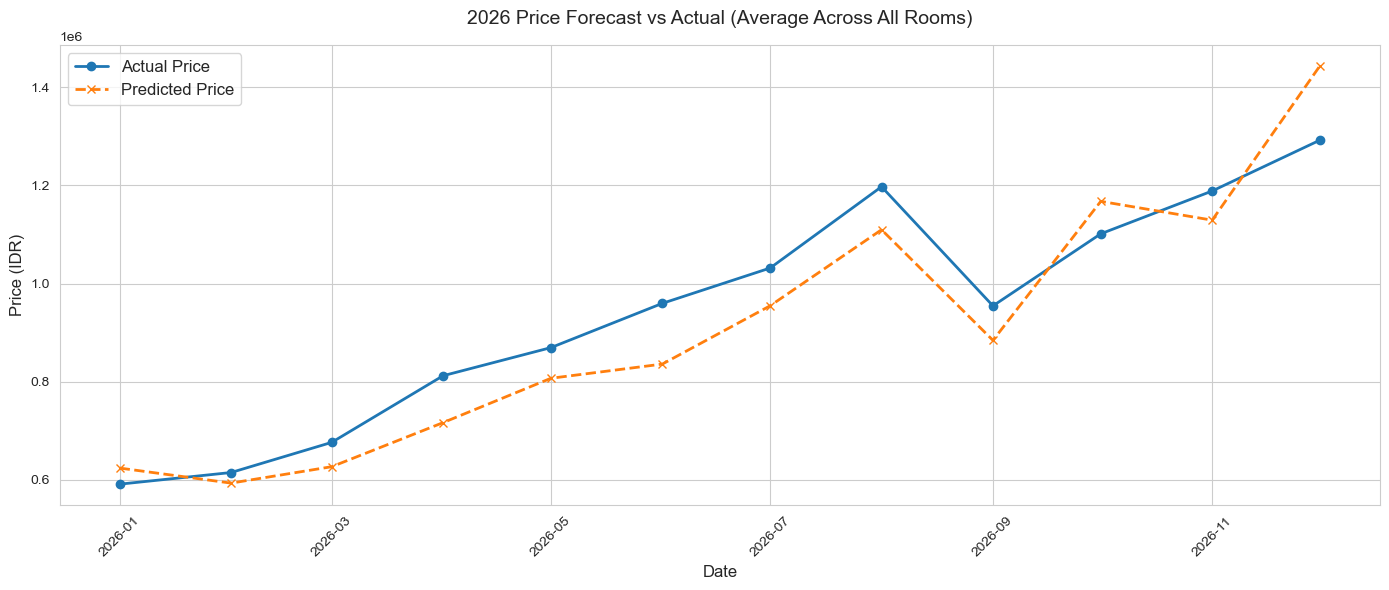


📊 Plotting Specific Trend for Room 354680.0...


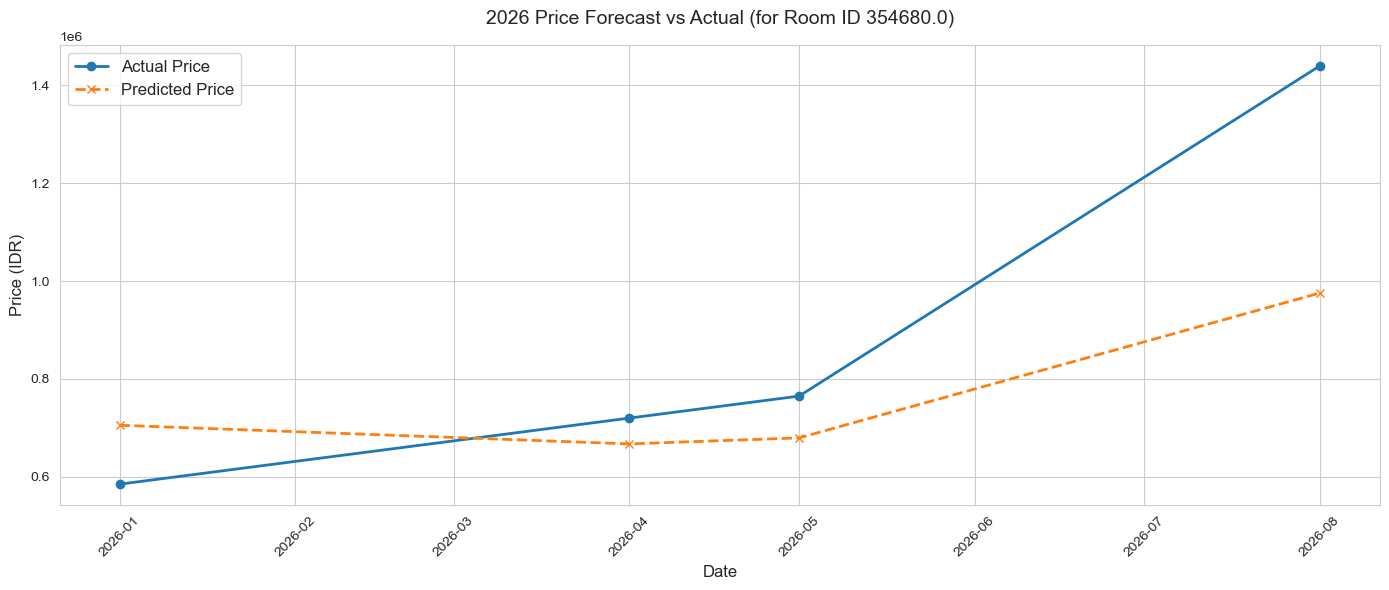

In [156]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# ... [KEEP ALL YOUR DATA SPLITTING & SETUP CODE HERE] ...

def train(params):
    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        # Use different variable names (X_trn, y_trn) so we don't overwrite global x_train
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] # These are Deltas!

        dtrain = lgb.Dataset(X_trn, label=y_trn, categorical_feature=['roomId', 'propertyId'])
        dvalid = lgb.Dataset(X_val, label=y_val, categorical_feature=['roomId', 'propertyId'], reference=dtrain)
        
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # Actual predicted price = Last month's base price + Predicted Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        val_score = np.sqrt(metrics.mean_squared_error(real_y_valid, final_y_pred_valid))
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning
        score = np.mean(mean_score)
        
        importance = clf.feature_importance(importance_type='gain')
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()

    # Outside the fold loop: Calculate the final predicted absolute prices for the Test Set
    final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
    
    # You can print out the true MAE of the holdout set here if you want to track it
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    test_r2 = metrics.r2_score(actual_test_prices, final_test_predictions)
    
    print(f'Final Holdout MAE : Rp {test_mae:,.0f}')
    print(f'Final Holdout R2  : {test_r2:.4f}')

    # Save predictions to the test dataframe so we can plot them!
    results_df = test_data.copy()
    results_df['predicted_price'] = final_test_predictions
    
    feature_names = clf.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    print(feat_imp)

    return results_df, clf

# ==========================================
# RUN TRAINING & GET RESULTS
# ==========================================
# Assuming `study.best_params` exists from your previous Optuna run
results_df, clf = train(study.best_params) 

# ==========================================
# PLOTTING THE 2026 FORECAST
# ==========================================
def plot_forecast(results_df, room_id=None):
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")
    
    if room_id:
        # Plot for a specific room
        plot_data = results_df[results_df['roomId'] == room_id].sort_values('date')
        title_suffix = f"for Room ID {room_id}"
    else:
        # Average the prices across all rooms per month
        plot_data = results_df.groupby('date')[['price', 'predicted_price']].mean().reset_index()
        title_suffix = "Average Across All Rooms"
        
    plt.plot(plot_data['date'], plot_data['price'], label='Actual Price', marker='o', linewidth=2, color='#1f77b4')
    plt.plot(plot_data['date'], plot_data['predicted_price'], label='Predicted Price', marker='x', linestyle='--', linewidth=2, color='#ff7f0e')
    
    plt.title(f"2026 Price Forecast vs Actual ({title_suffix})", fontsize=14, pad=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price (IDR)", fontsize=12)
    plt.legend(fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 1. Plot the overall macro trend (Average of all rooms)
print("\n📊 Plotting Average Hotel Trend...")
plot_forecast(results_df)

# 2. Plot a specific room (Replace with a real Room ID from your dataset)
sample_room = results_df['roomId'].unique()[0] 
print(f"\n📊 Plotting Specific Trend for Room {sample_room}...")
plot_forecast(results_df, room_id=sample_room)

In [60]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values('date').reset_index(drop=True)

# 2. SAFE FEATURE ENGINEERING: Calculate expanding mean to prevent target leakage
# This ensures the mean only looks at past data for that property, not future data.
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

# Features based on the safe mean
data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# 3. Split train and test AFTER safe feature engineering
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

# Drop rows where price_lag_1 is NaN (usually the first month of data)
train_data = train_data.dropna(subset=['price_lag_1']).reset_index(drop=True)
test_data = test_data.dropna(subset=['price_lag_1']).reset_index(drop=True)

# 4. FIX TARGET: Absolute Difference instead of Log Difference
# This stops exponential error multiplication when reconstructing prices
y_train = train_data['price'] - train_data['price_lag_1']

# Separate features
x_train = train_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# We still need these for testing
test = test_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')
actual_test_prices = test_data['price'].values
baseline_test_prices = test_data['price_lag_1'].values # Last month's price

# Define columns safely
columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
columns = list(set(columns).intersection(x_train.columns))

# Ensure categoricals are properly typed for LightGBM
for col in ['roomId', 'propertyId']:
    if col in columns:
        x_train[col] = x_train[col].astype('category')
        test[col] = test[col].astype('category')

# Define an objective function to be minimized
def objective(trial):
    params = {
        "objective": "mae",  # Changed to MAE to directly optimize for your goal
        "metric": "mae",     # Evaluate using MAE
        "boosting_type": "gbdt",
        "verbosity": -1,
        
        "num_boost_round": trial.suggest_int("num_boost_round", 300, 1500),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
        "max_depth": trial.suggest_int("max_depth", 3, 9),     
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 222,
    }

    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(x_train))
    n_fold = len(splits)
    
    test_diff_preds = np.zeros(test.shape[0])
    mean_score = []
    
    for fold_n, (train_index, valid_index) in enumerate(splits):
        
        X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
        y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 

        dtrain = lgb.Dataset(X_trn, label=y_trn)
        dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
        
        clf = lgb.train(
            params,
            dtrain,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
            ]
        )
        
        # Predict the DIFFERENCE for validation
        pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
        
        # FIX RECONSTRUCTION: Base price + Predicted Absolute Difference
        base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
        final_y_pred_valid = base_price_valid + pred_diff_valid
        
        # Real absolute prices for scoring
        real_y_valid = train_data['price'].iloc[valid_index].values
        
        # Calculate MAE for this fold
        val_score = metrics.mean_absolute_error(real_y_valid, final_y_pred_valid)
        mean_score.append(val_score)
        
        # Accumulate the DIFFERENCE predictions for the final Test set
        test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
        
        # Optuna Pruning based on CV score
        score = np.mean(mean_score)
        trial.report(score, fold_n)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Cleanup
        del X_trn, X_val, y_trn, y_val, dtrain, dvalid
        gc.collect()
        
        importance = clf.feature_importance(importance_type='gain')
    feature_names = clf.feature_name()

    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values(by='importance', ascending=False)

    # print(feat_imp)

    # Calculate final predictions for the Holdout Test Set
    final_test_predictions = baseline_test_prices + test_diff_preds
    
    # Track the Holdout MAE as a user attribute (so you can view it in Optuna plots)
    test_mae = metrics.mean_absolute_error(actual_test_prices, final_test_predictions)
    trial.set_user_attr("Holdout_MAE", test_mae)

    # FIX OPTUNA RETURN: Return the Cross-Validation MAE, NOT the Test MAE
    cv_mae = np.mean(mean_score)
    return cv_mae  

# Run Optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000) 

print("Best Params:", study.best_params)
print("Best CV MAE:", study.best_value)

[I 2026-04-03 01:14:19,864] A new study created in memory with name: no-name-93e9668c-c68c-4023-8ac8-56101b857035


[I 2026-04-03 01:14:22,246] Trial 0 finished with value: 112285.51824537183 and parameters: {'num_boost_round': 757, 'num_leaves': 50, 'max_depth': 3, 'min_data_in_leaf': 10, 'learning_rate': 0.022079817879329517, 'min_child_weight': 0.0021189102444753123, 'feature_fraction': 0.9191672179268654, 'bagging_fraction': 0.6574952733738872, 'bagging_freq': 7, 'reg_alpha': 0.0021441778880638474, 'reg_lambda': 0.1413682054240594}. Best is trial 0 with value: 112285.51824537183.
[I 2026-04-03 01:14:26,138] Trial 1 finished with value: 111882.19399660942 and parameters: {'num_boost_round': 1411, 'num_leaves': 24, 'max_depth': 6, 'min_data_in_leaf': 21, 'learning_rate': 0.017878737371818526, 'min_child_weight': 0.07345822835575114, 'feature_fraction': 0.7300239670047595, 'bagging_fraction': 0.8798466844211295, 'bagging_freq': 1, 'reg_alpha': 0.040459621632252744, 'reg_lambda': 0.12871776250698894}. Best is trial 1 with value: 111882.19399660942.
[I 2026-04-03 01:14:29,713] Trial 2 finished with v

KeyboardInterrupt: 

In [ ]:
Best Params: {'num_boost_round': 1338, 'num_leaves': 24, 'max_depth': 7, 'min_data_in_leaf': 20, 'learning_rate': 0.03692162860809076, 'min_child_weight': 0.0029730495727740636, 'feature_fraction': 0.6618999296881551, 'bagging_fraction': 0.7985344896919819, 'bagging_freq': 7, 'reg_alpha': 0.0615559663668795, 'reg_lambda': 0.06198632488623635}
Best CV MAE: 106827.4404586615

In [9]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
import gc

# 1. Pastikan data sudah terurut berdasarkan tanggal
data = data.sort_values(['roomId', 'date']).reset_index(drop=True)

# ---> Fix the 0 prices by filling them with adjacent months <---
data['price'] = data['price'].replace(0, np.nan)
data['price_lag_1'] = data['price_lag_1'].replace(0, np.nan)

data['price'] = data.groupby('roomId')['price'].transform(lambda x: x.ffill().bfill())
data['price_lag_1'] = data.groupby('roomId')['price_lag_1'].transform(lambda x: x.ffill().bfill())

# 2. SAFE FEATURE ENGINEERING
data['price_lag_1'] = data['price_lag_1'].astype(float)
data['property_mean_price'] = data.groupby('propertyId')['price_lag_1'].transform(lambda x: x.expanding().mean())

data['price_vs_property_mean'] = data['price_lag_1'] / data['property_mean_price']
data['price_diff_from_property'] = data['price_lag_1'] - data['property_mean_price']

# ==========================================
# 3. DIRECT MULTI-STEP TARGET CREATION
# ==========================================
for h in range(1, 13):
    data[f'target_step_{h}'] = data.groupby('roomId')['price'].shift(-(h-1))

studies = {}

# ==========================================
# 4. OPTIMIZATION LOOP FOR 12 MODELS
# ==========================================
def optimize_step(h, n_trials=30):
    print(f"\n{'='*50}")
    print(f"🚀 Optimizing Model for Step {h} (Predicting Month {h})")
    print(f"{'='*50}")

    step_data = data.dropna(subset=['price_lag_1', f'target_step_{h}']).reset_index(drop=True)

    train_data = step_data[step_data['date'] < '2026-01-01'].copy()
    test_data = step_data[step_data['date'] >= '2026-01-01'].copy()

    # ---> LOG TRANSFORMATION HERE <---
    # Target is now the log difference (log return) instead of absolute difference
    y_train = np.log1p(train_data[f'target_step_{h}']) - np.log1p(train_data['price_lag_1'])

    target_cols_to_drop = [f'target_step_{i}' for i in range(1, 13)]
    x_train = train_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')
    test = test_data.drop(columns=['price', 'date', 'month_period'] + target_cols_to_drop, errors='ignore')

    # Keep track of actuals for MAPE calculation (Raw original scale)
    actual_test_prices = test_data[f'target_step_{h}'].values
    baseline_test_prices = test_data['price_lag_1'].values

    columns = x_train.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
    columns = list(set(columns).intersection(x_train.columns))

    for col in ['roomId', 'propertyId']:
        if col in columns:
            x_train[col] = x_train[col].astype('category')
            test[col] = test[col].astype('category')

    def objective(trial):
        params = {
            "objective": "mae", 
            "metric": "mae",
            "boosting_type": "gbdt",
            "verbosity": -1,
            
            "num_boost_round": trial.suggest_int("num_boost_round", 300, 1000),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63), 
            "max_depth": trial.suggest_int("max_depth", 3, 9),     
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50), 
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 0.1, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 222,
        }

        tscv = TimeSeriesSplit(n_splits=5)
        splits = list(tscv.split(x_train))
        n_fold = len(splits)
        
        test_diff_preds = np.zeros(test.shape[0]) if len(test) > 0 else []
        mean_mape_score = []
        
        for fold_n, (train_index, valid_index) in enumerate(splits):
            X_trn, X_val = x_train[columns].iloc[train_index], x_train[columns].iloc[valid_index]
            y_trn, y_val = y_train.iloc[train_index], y_train.iloc[valid_index] 

            dtrain = lgb.Dataset(X_trn, label=y_trn)
            dvalid = lgb.Dataset(X_val, label=y_val, reference=dtrain)
            
            clf = lgb.train(
                params,
                dtrain,
                valid_sets=[dtrain, dvalid],
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
            
            # Predict LOG DIFFERENCE
            pred_diff_valid = clf.predict(X_val, num_iteration=clf.best_iteration)
            
            # ---> RECONSTRUCT PRICE UN-LOGGED <---
            base_price_valid = train_data['price_lag_1'].iloc[valid_index].values
            # Reconstruct: exp( log(base_price) + predicted_log_diff ) - 1
            final_y_pred_valid = np.expm1(np.log1p(base_price_valid) + pred_diff_valid)
            
            # GET REAL PRICE (Already un-logged)
            real_y_valid = train_data[f'target_step_{h}'].iloc[valid_index].values
            
            # --- EVALUATE WITH MAPE ---
            val_mape = metrics.mean_absolute_percentage_error(real_y_valid, final_y_pred_valid)
            mean_mape_score.append(val_mape)
            
            if len(test) > 0:
                test_diff_preds += clf.predict(test[columns], num_iteration=clf.best_iteration) / n_fold
            
            trial.report(np.mean(mean_mape_score), fold_n)
            if trial.should_prune():
                raise optuna.TrialPruned()
            
            del X_trn, X_val, y_trn, y_val, dtrain, dvalid
            gc.collect()

        # Calculate final MAPE for Holdout Test Set
        if len(test) > 0:
            # ---> RECONSTRUCT TEST PRICE UN-LOGGED <---
            final_test_predictions = np.expm1(np.log1p(baseline_test_prices) + test_diff_preds)
            test_mape = metrics.mean_absolute_percentage_error(actual_test_prices, final_test_predictions)
            trial.set_user_attr("Holdout_MAPE", test_mape)

        return np.mean(mean_mape_score)  

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials) 
    
    print(f"\n✅ Step {h} Finished | Best CV MAPE: {study.best_value:.4f}")
    return study

# Loop through and train 12 independent models
for step in range(1, 13):
    studies[step] = optimize_step(step, n_trials=1000)

[I 2026-04-03 02:39:44,554] A new study created in memory with name: no-name-83b2dc77-79fc-4a95-98df-11a16c2405ac



🚀 Optimizing Model for Step 1 (Predicting Month 1)


[I 2026-04-03 02:39:46,419] Trial 0 finished with value: 0.14983563693333105 and parameters: {'num_boost_round': 856, 'num_leaves': 31, 'max_depth': 4, 'min_data_in_leaf': 17, 'learning_rate': 0.0331558643032324, 'min_child_weight': 0.019615731070201762, 'feature_fraction': 0.9914783125241369, 'bagging_fraction': 0.6743105393623644, 'bagging_freq': 6, 'reg_alpha': 0.004499141883845101, 'reg_lambda': 1.807394607794539}. Best is trial 0 with value: 0.14983563693333105.
[I 2026-04-03 02:39:48,387] Trial 1 finished with value: 0.15049842237477948 and parameters: {'num_boost_round': 485, 'num_leaves': 29, 'max_depth': 5, 'min_data_in_leaf': 23, 'learning_rate': 0.01606990353566216, 'min_child_weight': 0.001282021131506953, 'feature_fraction': 0.7584290762338006, 'bagging_fraction': 0.8480377529279972, 'bagging_freq': 10, 'reg_alpha': 0.0029776461284005983, 'reg_lambda': 0.4355336543990583}. Best is trial 0 with value: 0.14983563693333105.
[I 2026-04-03 02:39:50,575] Trial 2 finished with va


✅ Step 1 Finished | Best CV MAPE: 0.1462

🚀 Optimizing Model for Step 2 (Predicting Month 2)


[I 2026-04-03 02:48:18,971] Trial 0 finished with value: 0.19959768958843555 and parameters: {'num_boost_round': 815, 'num_leaves': 35, 'max_depth': 4, 'min_data_in_leaf': 47, 'learning_rate': 0.026779486542222498, 'min_child_weight': 0.02689915689253885, 'feature_fraction': 0.6492498626862943, 'bagging_fraction': 0.7793390499940491, 'bagging_freq': 8, 'reg_alpha': 0.03191635829380901, 'reg_lambda': 9.51256064524841}. Best is trial 0 with value: 0.19959768958843555.
[I 2026-04-03 02:48:20,413] Trial 1 finished with value: 0.19870191092970277 and parameters: {'num_boost_round': 761, 'num_leaves': 25, 'max_depth': 4, 'min_data_in_leaf': 24, 'learning_rate': 0.042215142893001024, 'min_child_weight': 0.02912234149802296, 'feature_fraction': 0.8859903066117181, 'bagging_fraction': 0.647041954874101, 'bagging_freq': 1, 'reg_alpha': 0.022478686035314492, 'reg_lambda': 0.0012313645883422447}. Best is trial 1 with value: 0.19870191092970277.
[I 2026-04-03 02:48:22,106] Trial 2 finished with val

...


✅ Step 10 Finished | Best CV MAPE: 0.2377

🚀 Optimizing Model for Step 11 (Predicting Month 11)


[I 2026-04-03 04:10:24,403] Trial 0 finished with value: 0.22902600443781074 and parameters: {'num_boost_round': 468, 'num_leaves': 46, 'max_depth': 5, 'min_data_in_leaf': 47, 'learning_rate': 0.03307881916579626, 'min_child_weight': 0.006494116620354299, 'feature_fraction': 0.9707459371414504, 'bagging_fraction': 0.6563170287888062, 'bagging_freq': 2, 'reg_alpha': 0.13416183706062207, 'reg_lambda': 0.029245817657368774}. Best is trial 0 with value: 0.22902600443781074.
[I 2026-04-03 04:10:26,482] Trial 1 finished with value: 0.22422427221572203 and parameters: {'num_boost_round': 528, 'num_leaves': 15, 'max_depth': 6, 'min_data_in_leaf': 26, 'learning_rate': 0.014734933683155926, 'min_child_weight': 0.02956990696841207, 'feature_fraction': 0.8131932663033818, 'bagging_fraction': 0.7468468646028606, 'bagging_freq': 8, 'reg_alpha': 0.8363924862820635, 'reg_lambda': 0.4407042449296952}. Best is trial 1 with value: 0.22422427221572203.
[I 2026-04-03 04:10:28,256] Trial 2 finished with val


✅ Step 11 Finished | Best CV MAPE: 0.2186

🚀 Optimizing Model for Step 12 (Predicting Month 12)


[I 2026-04-03 04:19:33,165] Trial 0 finished with value: 0.22787874164767205 and parameters: {'num_boost_round': 603, 'num_leaves': 26, 'max_depth': 5, 'min_data_in_leaf': 13, 'learning_rate': 0.02352133391822123, 'min_child_weight': 0.03267998366162774, 'feature_fraction': 0.8332865504386082, 'bagging_fraction': 0.7123693311873889, 'bagging_freq': 4, 'reg_alpha': 0.04245877869062642, 'reg_lambda': 1.1374915414532847}. Best is trial 0 with value: 0.22787874164767205.
[I 2026-04-03 04:19:34,615] Trial 1 finished with value: 0.23086511832373016 and parameters: {'num_boost_round': 317, 'num_leaves': 23, 'max_depth': 5, 'min_data_in_leaf': 25, 'learning_rate': 0.022372271373659543, 'min_child_weight': 0.06622150895189857, 'feature_fraction': 0.6575532099765248, 'bagging_fraction': 0.7186909159237386, 'bagging_freq': 9, 'reg_alpha': 9.97541983254438, 'reg_lambda': 4.018717827891338}. Best is trial 0 with value: 0.22787874164767205.
[I 2026-04-03 04:19:35,975] Trial 2 finished with value: 0.


✅ Step 12 Finished | Best CV MAPE: 0.2174


In [10]:
for i in range(1, 13):
    print(f"Bulan ke-{i} Best CV MAPE (Persentase error dari prediksi): {(studies[i].best_value*100):.2f}%, Holdout MAPE: {studies[i].best_trial.user_attrs['Holdout_MAPE']:.4f}")

Bulan ke-1 Best CV MAPE (Persentase error dari prediksi): 14.62%, Holdout MAPE: 0.1797
Bulan ke-2 Best CV MAPE (Persentase error dari prediksi): 18.89%, Holdout MAPE: 0.2035
Bulan ke-3 Best CV MAPE (Persentase error dari prediksi): 20.54%, Holdout MAPE: 0.2548
Bulan ke-4 Best CV MAPE (Persentase error dari prediksi): 22.69%, Holdout MAPE: 0.2879
Bulan ke-5 Best CV MAPE (Persentase error dari prediksi): 23.33%, Holdout MAPE: 0.2781
Bulan ke-6 Best CV MAPE (Persentase error dari prediksi): 24.25%, Holdout MAPE: 0.2287
Bulan ke-7 Best CV MAPE (Persentase error dari prediksi): 24.00%, Holdout MAPE: 0.1667
Bulan ke-8 Best CV MAPE (Persentase error dari prediksi): 24.30%, Holdout MAPE: 0.1226
Bulan ke-9 Best CV MAPE (Persentase error dari prediksi): 24.59%, Holdout MAPE: 0.1248
Bulan ke-10 Best CV MAPE (Persentase error dari prediksi): 23.77%, Holdout MAPE: 0.1246
Bulan ke-11 Best CV MAPE (Persentase error dari prediksi): 21.86%, Holdout MAPE: 0.1564
Bulan ke-12 Best CV MAPE (Persentase erro

In [82]:
for i in range(1, 13):
    print(f"Bulan ke-{i} Best CV MAPE (Persentase error dari prediksi): {(studies[i].best_value*100):.2f}%, Holdout MAPE: {studies[i].best_trial.user_attrs['Holdout_MAPE']:.4f}")

Bulan ke-1 Best CV MAPE (Persentase error dari prediksi): 14.80%, Holdout MAPE: 0.1824
Bulan ke-2 Best CV MAPE (Persentase error dari prediksi): 19.28%, Holdout MAPE: 0.2104
Bulan ke-3 Best CV MAPE (Persentase error dari prediksi): 21.99%, Holdout MAPE: 0.2611
Bulan ke-4 Best CV MAPE (Persentase error dari prediksi): 23.63%, Holdout MAPE: 0.2894
Bulan ke-5 Best CV MAPE (Persentase error dari prediksi): 24.35%, Holdout MAPE: 0.2808
Bulan ke-6 Best CV MAPE (Persentase error dari prediksi): 25.70%, Holdout MAPE: 0.2232
Bulan ke-7 Best CV MAPE (Persentase error dari prediksi): 25.31%, Holdout MAPE: 0.1623
Bulan ke-8 Best CV MAPE (Persentase error dari prediksi): 25.74%, Holdout MAPE: 0.1174
Bulan ke-9 Best CV MAPE (Persentase error dari prediksi): 25.40%, Holdout MAPE: 0.1117
Bulan ke-10 Best CV MAPE (Persentase error dari prediksi): 24.83%, Holdout MAPE: 0.1255
Bulan ke-11 Best CV MAPE (Persentase error dari prediksi): 22.38%, Holdout MAPE: 0.1393
Bulan ke-12 Best CV MAPE (Persentase erro

In [76]:
studies[1].best_trial.user_attrs 

{'Holdout_MAPE': 0.18244158630555612}

In [66]:
data[data['price'] <= 0]

,month_period,propertyId,roomId,price,year,month,total_capacity_nights,date,quarter,season_strength,is_peak_season,is_eid_month,is_major_holiday_month,price_lag_1,price_lag_2,price_lag_3,price_lag_6,price_lag_12,price_roll_mean_3,price_roll_std_3,price_roll_max_3,price_roll_min_3,price_roll_mean_6,price_roll_std_6,price_roll_max_6,price_roll_min_6,price_roll_mean_12,price_roll_std_12,price_roll_max_12,price_roll_min_12,price_diff_1,price_diff_12,price_growth_1,price_ema_3,used_room_nights_lag_1,used_room_nights_lag_2,used_room_nights_lag_12,used_room_nights_roll_mean_3,leftover_rooms_lag_1,leftover_rooms_lag_2,leftover_rooms_lag_12,leftover_rooms_roll_mean_3,range_booking_arrival_lag_1,range_booking_arrival_lag_2,range_booking_arrival_lag_12,range_booking_arrival_roll_mean_3,num_of_nights_lag_1,num_of_nights_lag_2,num_of_nights_lag_12,num_of_nights_roll_mean_3,commission_lag_1,commission_lag_2,commission_lag_12,commission_roll_mean_3,numChild_lag_1,numChild_lag_2,numChild_lag_12,numChild_roll_mean_3,occupancy_trend,masterId_lag_1,status_confirmed_lag_1,status_new_lag_1,subStatus_noShow_lag_1,subStatus_nonPayment_lag_1,subStatus_none_lag_1,subStatus_walkin_lag_1,title_Honeymoon_decor_lag_1,title_RO_lag_1,title_Teman_kim_kasih_breakfast_lag_1,title_Twin_bed_lag_1,arrivalTime_16_30_lag_1,arrivalTime___lag_1,voucher_geniuscm_lag_1,groupNote_Room_Only__lag_1,custom1_Paid_OTA_lag_1,custom1_Paid_by_OTA_Auto_Adjusted_lag_1,referer_Booking_com_lag_1,refererEditable_Booking_com_lag_1,reference_45867993_marie_lag_1,reference_E5593226_ANNA_HUBER_lag_1,reference_EJ4657377__lag_1,reference_PAL643451_LUCAS_lag_1,reference_PAM228132_lag_1,reference_YB7740043_lag_1,channel_booking_lag_1,apiSource_Booking_com_lag_1,allowChannelUpdate_all_lag_1,allowAutoAction_disable_lag_1,allowAutoAction_enable_lag_1,allowReview_default_lag_1,allowCancellation__type_propertyDefault__lag_1,cancelTime_2024_08_05T03_15_10Z_lag_1,year_month_lag_1,review_count_lag_1,avg_review_score_lag_1,avg_facilities_score_lag_1,avg_comfort_score_lag_1,avg_staff_score_lag_1,avg_value_score_lag_1,avg_clean_score_lag_1,avg_location_score_lag_1,tfidf_beach_lag_1,tfidf_clean_lag_1,tfidf_da_lag_1,tfidf_de_lag_1,tfidf_der_lag_1,tfidf_die_lag_1,tfidf_el_lag_1,tfidf_en_lag_1,tfidf_est_lag_1,tfidf_et_lag_1,tfidf_friendly_lag_1,tfidf_good_lag_1,tfidf_great_lag_1,tfidf_hotel_lag_1,tfidf_la_lag_1,tfidf_le_lag_1,tfidf_location_lag_1,tfidf_muy_lag_1,tfidf_nice_lag_1,tfidf_place_lag_1,tfidf_pool_lag_1,tfidf_que_lag_1,tfidf_room_lag_1,tfidf_sehr_lag_1,tfidf_staff_lag_1,tfidf_stay_lag_1,tfidf_super_lag_1,tfidf_trs_lag_1,tfidf_un_lag_1,tfidf_und_lag_1,price_to_mean_ratio,price_vs_property_avg,occupancy_price_interaction,price_vs_roll_mean_12,price_vs_roll_mean_6,trend_3_vs_12,trend_slope,price_vs_property_mean,price_zscore_property,season_price_interaction,peak_price_interaction,growth_season_interaction,occupancy_season_interaction,global_month_mean_price,property_month_mean_price,property_mean_price,price_diff_from_property,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10,target_step_11,target_step_12
936,2026-03,194837.0,419104.0,0.0,2026,3,62,2026-03-01,1,1,0,1,1,157950.00,150093.000000,299362.500000,634666.258333,217350.000000,202468.500000,84004.574514,299362.500000,150093.00,338834.000198,182781.783179,634666.258333,150093.00,407516.377015,228341.619209,966922.941176,150093.00,7857.000000,-59400.000000,0.052348,210728.493537,4.0,15.0,19.0,13.666667,52.0,47.0,43.0,46.333333,26.00,5.00,11.250000,13.222222,2.00,2.400000,2.750000,2.244444,47385.0,43168.800000,84138.750000,58557.100000,1.5,0.0,0.000000,0.5,-11.0,6.897610e+07,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2026_02,0.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111101,0.0,0.127273,0.0,0.133326,0.0,0.0,0.

In [138]:
df_rooms = pd.read_csv("../data/raw/room_qty.csv")
df_rooms = df_rooms.rename(columns={'room_id': 'roomId', 'quantity': 'qty'})

⚙️ Training final production model...
🔮 Starting blind 2027 forecast...
✅ Forecasted 2027-01
✅ Forecasted 2027-02
✅ Forecasted 2027-03
✅ Forecasted 2027-04
✅ Forecasted 2027-05
✅ Forecasted 2027-06
✅ Forecasted 2027-07
✅ Forecasted 2027-08
✅ Forecasted 2027-09
✅ Forecasted 2027-10
✅ Forecasted 2027-11
✅ Forecasted 2027-12


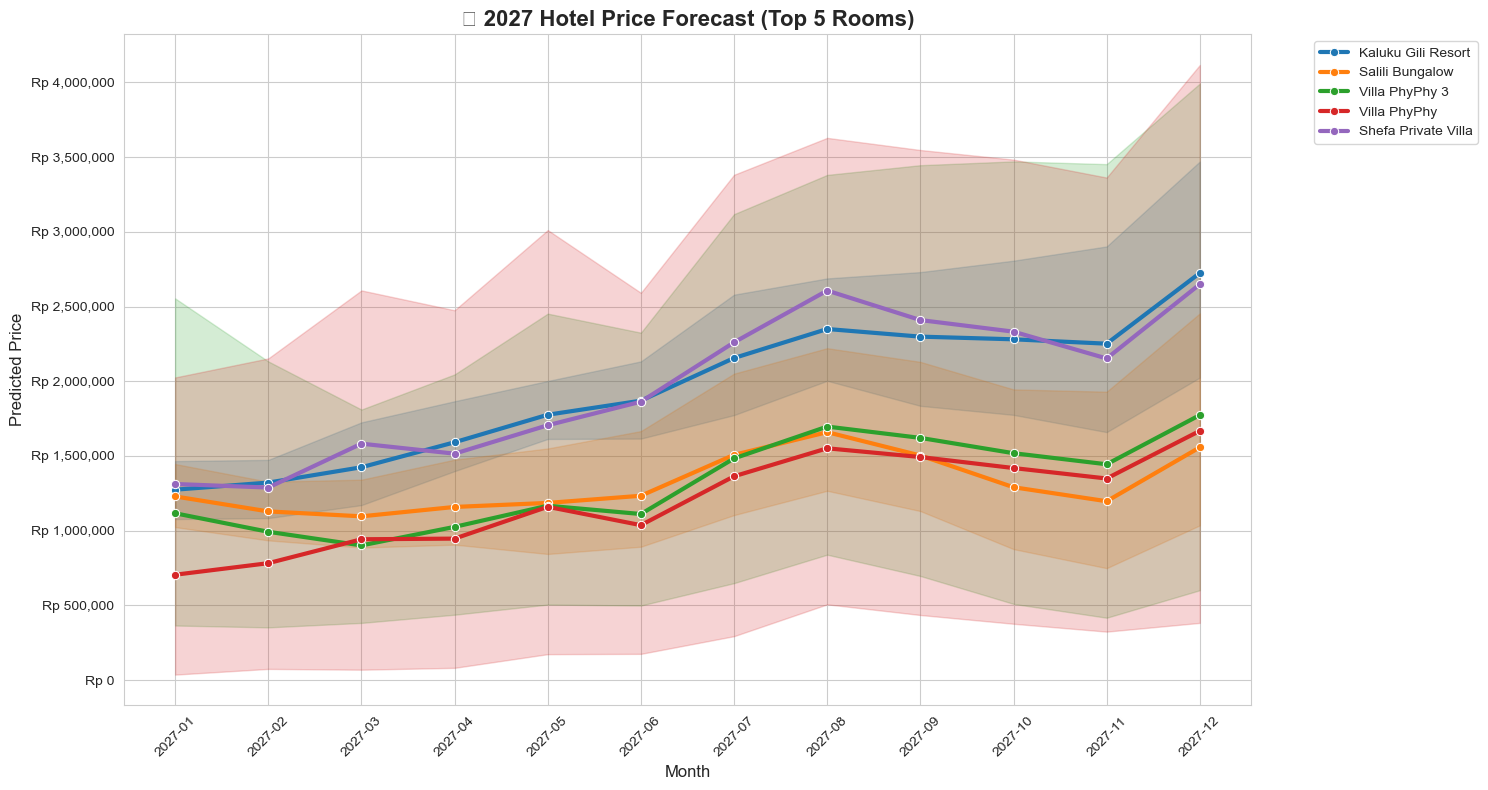

In [144]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# 1. Train the FINAL model
print("⚙️ Training final production model...")
y_full = data['price'] - data['price_lag_1']
x_full = data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# Identify features and categorical columns
columns = x_full.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId']
columns = list(set(columns).intersection(x_full.columns))

dtrain_full = lgb.Dataset(x_full[columns], label=y_full, categorical_feature=['roomId', 'propertyId'])
final_model = lgb.train(study.best_params, dtrain_full, num_boost_round=1000)

# Pre-fetch categories to avoid the "categorical mismatch" error
room_cats = x_full['roomId'].astype('category').cat.categories
prop_cats = x_full['propertyId'].astype('category').cat.categories

# 2. Setup the 2027 Iterative Loop
print("🔮 Starting blind 2027 forecast...")
# Use original raw 'df' to ensure all columns (commission, etc.) are available for FE
historical_base = df.copy()
historical_base['month_period'] = historical_base['month_period'].astype(str)

months_2027 = pd.date_range(start='2027-01-01', end='2027-12-01', freq='MS').strftime('%Y-%m')
unique_rooms = historical_base['roomId'].unique()
future_predictions = []

for target_month in months_2027:
    # A. Create Skeleton
    dummy_df = pd.DataFrame({'roomId': unique_rooms})
    dummy_df['month_period'] = target_month
    
    # B. Seasonal Proxy (Forward-fill stats from same month in 2026)
    target_month_num = int(target_month.split('-')[1])
    last_year_data = historical_base[pd.to_datetime(historical_base['month_period']).dt.month == target_month_num]
    
    # Get numeric columns needed for features (excluding price/IDs)
    cols_to_fill = last_year_data.select_dtypes(include='number').columns.tolist()
    cols_to_fill = [c for c in cols_to_fill if c not in ['roomId', 'propertyId', 'price']]
    
    avg_metrics = last_year_data.groupby('roomId')[cols_to_fill].mean().reset_index()
    dummy_df = dummy_df.merge(avg_metrics, on='roomId', how='left')
    
    # Map propertyId and init price
    prop_map = historical_base.drop_duplicates('roomId').set_index('roomId')['propertyId'].to_dict()
    dummy_df['propertyId'] = dummy_df['roomId'].map(prop_map)
    dummy_df['price'] = np.nan 

    # C. Feature Engineering
    combined_raw = pd.concat([historical_base, dummy_df], ignore_index=True)
    featurized = advanced_hybrid_fe(combined_raw) 
    
    # --- CRITICAL FIX FOR KEYERROR ---
    # Ensure roomId and month_period are columns, not indices
    if 'roomId' not in featurized.columns: featurized = featurized.reset_index()
    if 'month_period' not in featurized.columns: featurized = featurized.reset_index()

    # D. Isolate Target Month & Align Categories
    target_x = featurized[featurized['month_period'] == target_month].copy()
    
    if target_x.empty:
        print(f"⚠️ Warning: No data for {target_month}. Check FE logic.")
        continue

    target_x['roomId'] = pd.Categorical(target_x['roomId'], categories=room_cats)
    target_x['propertyId'] = pd.Categorical(target_x['propertyId'], categories=prop_cats)
    
    # E. Predict Price (Lag + Predicted Delta)
    pred_delta = final_model.predict(target_x[columns])
    final_price = target_x['price_lag_1'].values + pred_delta
    
    # F. Update the Historical Base (FEEDBACK LOOP)
    # We update both dummy_df (for next concat) and historical_base
    dummy_df['price'] = final_price
    historical_base = pd.concat([historical_base, dummy_df], ignore_index=True)
    
    # Save results for plotting
    target_x['predicted_price'] = final_price
    future_predictions.append(target_x[['roomId', 'month_period', 'predicted_price']])
    
    print(f"✅ Forecasted {target_month}")

# 3. Merge Room Names
df_2027 = pd.concat(future_predictions)
df_rooms = pd.read_csv("../data/raw/room_qty.csv")
# Find the right name column
name_col = [c for c in ['roomName', 'name', 'room_type'] if c in df_rooms.columns]
name_col = name_col[0] if name_col else df_rooms.columns[1]

df_rooms = df_rooms.rename(columns={'room_id': 'roomId', 'quantity': 'qty'})
df_2027 = df_2027.merge(df_rooms[['roomId', name_col]], on='roomId', how='left')

# 4. Final Visualization
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Select top rooms to avoid a messy chart
top_rooms = df_2027.groupby(name_col)['predicted_price'].mean().nlargest(5).index
plot_df = df_2027[df_2027[name_col].isin(top_rooms)].sort_values('month_period')

sns.lineplot(data=plot_df, x='month_period', y='predicted_price', hue=name_col, marker='o', linewidth=3)

# Formatting the Y-axis for Rupiah
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x:,.0f}'))

plt.title("🚀 2027 Hotel Price Forecast (Top 5 Rooms)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

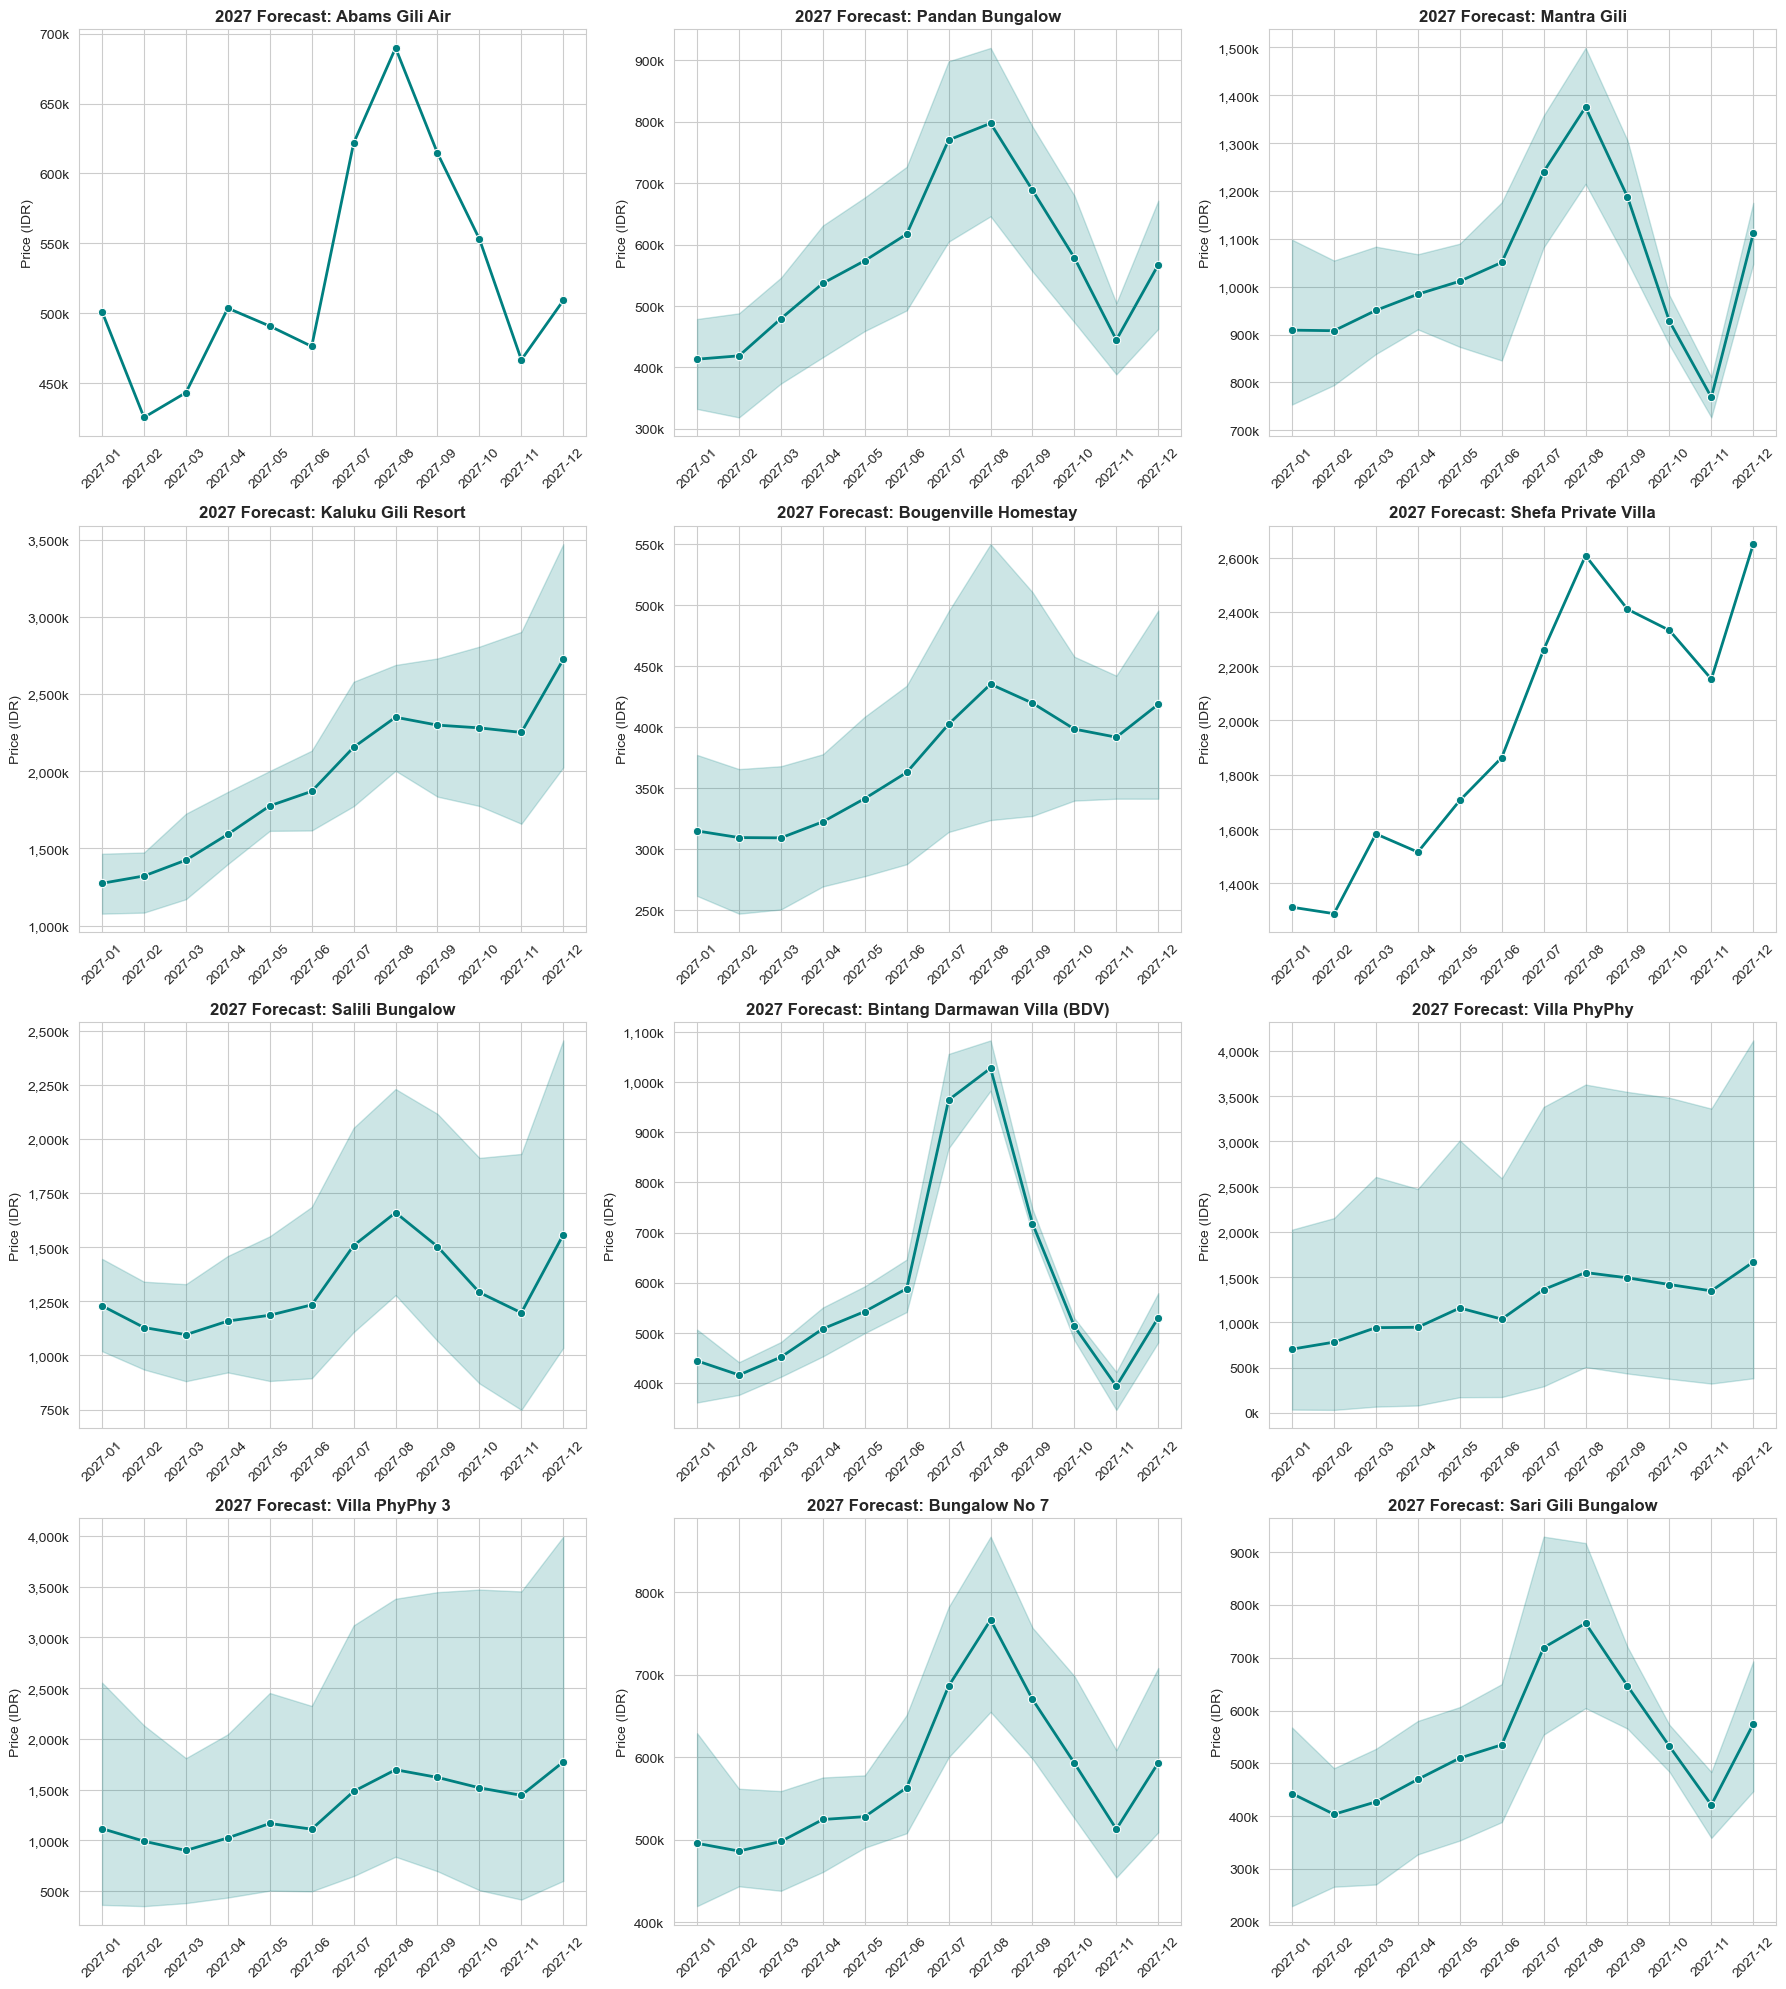

In [145]:
# 4. Final Visualization - Individual Plots for All Rooms
import math

# Get the list of all unique rooms that were forecasted
all_rooms = df_2027[name_col].unique()
n_rooms = len(all_rooms)

# Calculate grid size (3 columns wide)
n_cols = 3
n_rows = math.ceil(n_rooms / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # Flatten to 1D array for easy looping

sns.set_style("whitegrid")

for i, room_name in enumerate(all_rooms):
    ax = axes[i]
    
    # Filter data for this specific room
    plot_df = df_2027[df_2027[name_col] == room_name].sort_values('month_period')
    
    # Plot
    sns.lineplot(data=plot_df, x='month_period', y='predicted_price', 
                 marker='o', color='teal', ax=ax, linewidth=2)
    
    # Title and Labels
    ax.set_title(f"2027 Forecast: {room_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("") # Hide x-label to save space
    ax.set_ylabel("Price (IDR)")
    
    # Format Y-axis to Rupiah
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e3:,.0f}k'))
    
    # Rotate x-ticks for readability
    ax.tick_params(axis='x', rotation=45)

# Remove any empty subplots at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [140]:
df_2027

,roomId,month_period,predicted_price
46,350455.0,2027-01,5.010378e+05
92,350464.0,2027-01,4.244671e+05
138,354680.0,2027-01,8.756762e+05
184,354681.0,2027-01,7.130643e+05
234,354682.0,2027-01,1.172249e+06
284,354683.0,2027-01,8.757304e+05
338,359135.0,2027-01,1.077719e+06
393,359136.0,2027-01,1.279916e+06
447,359142.0,2027-01,1.465847e+06
483,370147.0,2027-01,2.487444e+05


In [137]:
df_rooms

,property_id,property_name,room_id,room_name,quantity
0,158986,Abams Gili Air,350455,Double Room with Terrace,8
1,158990,Pandan Bungalow,350464,Superior Bungalow,5
2,158990,Pandan Bungalow,462631,Superior Single,1
3,158990,Pandan Bungalow,462632,Deluxe Room,4
4,158990,Pandan Bungalow,462634,Wooden Deluxe Bungalow,2
5,158990,Pandan Bungalow,502851,Deluxe Bungalow,1
6,161014,Mantra Gili,354680,King Room with Balcony,1
7,161014,Mantra Gili,354681,King Room with Pool View,1
8,161014,Mantra Gili,354682,Deluxe Double or Twin Room with Pool Access,4
9,161014,Mantra Gili,354683,Deluxe Double or Twin Room with Balcony,4


In [113]:
# 1. Pastikan data sudah terurut berdasarkan tanggal

data = data.sort_values('date').reset_index(drop=True)
# data = data[useful_features]
# 1. Split train and test first!
train_data = data[data['date'] < '2026-01-01'].copy()
test_data = data[data['date'] >= '2026-01-01'].copy()

# 2. Calculate the average price per room and property ONLY from Train
room_avg_price = train_data.groupby('roomId')['price'].mean().to_dict()
property_avg_price = train_data.groupby('propertyId')['price'].mean().to_dict()

# 3. Map these averages back to both Train and Test sets
train_data['room_historical_avg'] = train_data['roomId'].map(room_avg_price)
train_data['prop_historical_avg'] = train_data['propertyId'].map(property_avg_price)

test_data['room_historical_avg'] = test_data['roomId'].map(room_avg_price)
test_data['prop_historical_avg'] = test_data['propertyId'].map(property_avg_price)

# Add these new columns ('room_historical_avg', 'prop_historical_avg') to your useful_features list!

# 3. Definisikan X dan Y untuk Training (Wajib dari sumber yang sama yaitu train_data)
y = np.log1p(train_data['price'])  # Log-transform HARUS diambil dari train_data!
x = train_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# 4. Definisikan Test Set
test = test_data.drop(columns=['price', 'date', 'month_period'], errors='ignore')

# Simpan harga asli test untuk perhitungan RMSE di akhir (bukan untuk training)
test_actual_price = test_data['price']

# x = data.drop(columns=['price'])
# Define an objective function to be minimized.
def train(params):
    columns = x.select_dtypes(include='number').columns.to_list() + ['roomId', 'propertyId'] 
    # print(columns)
    splits = folds.split(x, y)
    y_preds = np.zeros(test.shape[0])
    y_oof = np.zeros(x.shape[0])
    feature_importances = pd.DataFrame()
    feature_importances['feature'] = columns
    mean_score = []
    mean_score_mae = []
    mean_score_r2 = []
    for fold_n, (train_index, valid_index) in enumerate(splits):
        X_train, X_valid = x[columns].iloc[train_index], x[columns].iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
        dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=['roomId', 'propertyId', 'month', 'year'])
        dvalid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=['roomId', 'propertyId', 'month', 'year'])
        clf = lgb.train(
            params,
            dtrain,
            num_boost_round=2500,
            valid_sets=[dtrain, dvalid],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )
        feature_importances[f'fold_{fold_n + 1}'] = clf.feature_importance()

        y_pred_valid = np.expm1(clf.predict(X_valid, num_iteration=clf.best_iteration))
        actual_y_valid = np.expm1(y_valid)
        
        val_score = np.sqrt(metrics.mean_squared_error(y_pred_valid, actual_y_valid))
        val_score_mae = metrics.mean_absolute_error(y_pred_valid, actual_y_valid)
        val_score_r2 = metrics.r2_score(y_pred_valid, actual_y_valid)
        
        mean_score.append(val_score)
        mean_score_mae.append(val_score_mae)
        mean_score_r2.append(val_score_r2)
        y_preds += np.expm1(clf.predict(test[columns], num_iteration=clf.best_iteration))/n_fold
        
        score = np.mean(mean_score)
        
        # Delete ga penting baut memory
        del X_train, X_valid, y_train, y_valid
        gc.collect()
    # print('mean rmse score over folds is', score)
    test['price'] = y_preds
    
    # Rata-ratakan pentingnya fitur dari semua fold
    print(f'mae : {np.mean(mean_score_mae)}')
    print(f'r2 : {np.mean(mean_score_r2)}')
    
    feature_importances['mean_importance'] = feature_importances[[col for col in feature_importances.columns if 'fold' in col]].mean(axis=1)

    # # Urutkan dari yang paling penting ke yang tidak berguna
    important_features = feature_importances.sort_values('mean_importance', ascending=False)
    print(important_features[['feature', 'mean_importance']].head(20)) # 20 Fitur terbaik
    print(important_features[['feature', 'mean_importance']].tail(20)) # 20 Fitur ampas
    return score  # An objective value linked with the Trial object.

train(params=study.best_params)

mae : 115948.26250259514
r2 : 0.4702641229514634
                              feature  mean_importance
66                room_historical_avg       593.333333
25                       price_diff_1       382.333333
67                             roomId       361.666667
27                     price_growth_1       336.000000
8                         price_lag_1       333.666667
11                        price_lag_6       327.000000
1                               month       325.333333
18                   price_roll_std_6       316.666667
41                num_of_nights_lag_1       282.000000
38        range_booking_arrival_lag_2       268.333333
14                   price_roll_std_3       262.666667
45                   commission_lag_1       254.666667
10                        price_lag_3       248.000000
46                   commission_lag_2       246.000000
40  range_booking_arrival_roll_mean_3       240.333333
44          num_of_nights_roll_mean_3       233.000000
53              

np.float64(231194.17855029236)

In [ ]:
mae : 114948.40328619613
                              feature  mean_importance
83                room_historical_avg       870.333333
1                               month       745.333333
8                         price_lag_6       740.000000
50                    occupancy_trend       711.333333
84                             roomId       665.333333
22                       price_diff_1       653.666667
34        range_booking_arrival_lag_1       640.333333
24                     price_growth_1       632.000000
15                   price_roll_std_6       614.000000
5                         price_lag_1       573.000000
35        range_booking_arrival_lag_2       546.000000
11                   price_roll_std_3       537.333333
38                num_of_nights_lag_1       513.000000
7                         price_lag_3       495.666667
37  range_booking_arrival_roll_mean_3       493.000000
41          num_of_nights_roll_mean_3       480.333333
42                   commission_lag_1       479.000000
43                   commission_lag_2       465.000000
39                num_of_nights_lag_2       462.333333
6                         price_lag_2       423.666667
                                           feature  mean_importance
66         custom1_Paid_by_OTA_Auto_Adjusted_lag_1              0.0
57                     title_Honeymoon_decor_lag_1              0.0
62                             arrivalTime___lag_1              0.0
54                      subStatus_nonPayment_lag_1              0.0
69                  reference_45867993_marie_lag_1              0.0
68               refererEditable_Booking_com_lag_1              0.0
67                       referer_Booking_com_lag_1              0.0
70             reference_E5593226_ANNA_HUBER_lag_1              0.0
74                       reference_YB7740043_lag_1              0.0
71                      reference_EJ4657377__lag_1              0.0
72                 reference_PAL643451_LUCAS_lag_1              0.0
73                       reference_PAM228132_lag_1              0.0
77                    allowChannelUpdate_all_lag_1              0.0
76                     apiSource_Booking_com_lag_1              0.0
75                           channel_booking_lag_1              0.0
78                   allowAutoAction_disable_lag_1              0.0
81  allowCancellation__type_propertyDefault__lag_1              0.0
80                       allowReview_default_lag_1              0.0
79                    allowAutoAction_enable_lag_1              0.0
82           cancelTime_2024_08_05T03_15_10Z_lag_1              0.0
np.float64(228234.91215105064)

In [ ]:
mae : 118296.08307347175
                  feature  mean_importance
2                   lag_6       993.666667
0                      id       981.666667
15        commission_lag1       819.000000
5          subStatus_none       814.000000
4                   lag_1       802.000000
6                growth_1       786.666667
11             roll_std_3       784.000000
1                   lag_3       769.666667
12             roll_std_6       677.333333
19    room_historical_avg       670.666667
7                  diff_1       637.666667
8                 diff_12       627.333333
3                   lag_2       583.333333
13            roll_std_12       546.000000
9                   month       488.000000
14            roll_mean_6       458.333333
17  status_confirmed_lag1       456.000000
16       status_confirmed       436.666667
20                 roomId       424.333333
10        season_strength       301.666667
                  feature  mean_importance
15        commission_lag1       819.000000
5          subStatus_none       814.000000
...
20                 roomId       424.333333
10        season_strength       301.666667
21             propertyId       107.000000
18                   year        10.333333
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
np.float64(231105.17619796595)

In [105]:
# Rata-ratakan pentingnya fitur dari semua fold
feature_importances['mean_importance'] = feature_importances[[col for col in feature_importances.columns if 'fold' in col]].mean(axis=1)

# Urutkan dari yang paling penting ke yang tidak berguna
important_features = feature_importances.sort_values('mean_importance', ascending=False)
print(important_features[['feature', 'mean_importance']].head(20)) # 20 Fitur terbaik
print(important_features[['feature', 'mean_importance']].tail(20)) # 20 Fitur ampas

             feature  mean_importance
5              price      1793.666667
6         commission       889.666667
44            lag_t2       824.000000
43            lag_t1       728.333333
46   rolling_mean_t1       464.333333
1                 id       444.333333
50    rolling_std_t0       429.333333
2           masterId       416.333333
8   status_confirmed       384.666667
0             roomId       364.000000
49   rolling_mean_t3       350.333333
48   rolling_mean_t2       348.666667
45            lag_t3       280.000000
3         propertyId       275.666667
10        status_new       259.000000
42             month       101.000000
4           numChild        48.333333
41              year        21.666667
7       status_black         0.000000
18    title_Twin_bed         0.000000
                                     feature  mean_importance
23                          custom1_Paid_OTA              0.0
24         custom1_Paid_by_OTA_Auto_Adjusted              0.0
25              